Тематика проекта: аналитика маркетплейса

Этапы проекта: 
1. Первичный анализ и сбор данных, построение витрин данных
2. Обзор ключевых метрик
3. Оценка метрик монетизации и юнит-экономики
4. Поиск инсайтов и точек роста, сегментация и формулирование гипотез

Цель анализа: есть данные быстрорастущего маркетплейса, которые раньше никто системно не анализировал. Необходимо погрузиться в них и собрать целостную картину: от первых шагов пользователей до монетизации и возврата. Также есть требование провести сегментацию по каналам привлечения пользователей

### Дерево метрик — для удобства дальнейшей работы

##### Метрики маркетплейсов (справка):

Замечание: анализируем только сторону покупателей на маркетплейсе, про продавцов ничего не знаем<br>

1. **Бизнес-метрики**
    - `GMV` — Gross Merchandise Value — общая стоимость товаров или услуг, проданных через маркетплейс в период времени
    - `Net Revenue` = GMV * Take rate — Произведение валовой стоимости товаров на Take rate показывает фактический доход маркетплейса от комиссий за транзакции на платформе. Знаем, что выручка бизнеса в нашем случае — 5% комиссии от стоимости любой продажи
    - `COGS` - Cost of Goods Sold — в COGS маркетплейса НЕ входит закупочная стоимость товара, так как маркетплейс обычно не закупает товар для продажи. Вместо этого в COGS могут входить операционные расходы, связанные с обеспечением транзакций на платформе, такие как расходы на обработку платежей, обслуживание клиентов, маркетинг и развитие технологий. У нас есть расходы на маркетинговые кампании и SEO, можно рассчитать их
    - `Gross margin` = (Net Revenue - COGS) / Net Revenue — процент прибыли, который остается после вычета стоимости проданных товаров
    - `AOV` - Average Order Value — средняя стоимость заказа на маркетплейсе за определенный период
    - `ARPU` - Average Revenue per User - средняя выручка на одного пользователя за определённый промежуток времени
    - `ARPPU` - Average Revenue per Paying User - средняя выручка от одного платящего пользователя за определённый период
    - `CAC` - Customer Acquisition Cost — стоимость привлечения одного клиента
    - `LTV` на 28-ой день (1 месяц) / на 56-ой день (2 месяца) — сколько денег клиент приносит компании за определенное время взаимодействия с ней
    - `ROI` на 28-ой день (месяц) / на 56-ой день (2 месяца) — окупаемость вложений в процентах
    - `payback period` — момент, в который LTV становится равен CAC


2. **Продуктовые метрики**
    - `new users` - кол-во привлеченных пользователей за определенный промежуток времени
    - `active users (DAU, WAU, MAU)` — кол-во уникальных активных пользователей (пользователей, которые заходили на ресурс) за определенный промежуток времени
    - `Sticky Factor` (avgDau / MAU) — чем выше метрика, тем больше людей «залипают» в продукте ежедневно, показывает регулярную вовлечённость пользователей
    - `Число транзакций` — кол-во покупок в определенный промежуток времени
    - `Retention Rate` 2, 7, 28 — процент пользователей, которые продолжают использовать продукт спустя какое-то время после первого взаимодействия
    - `Churn Rate` (противоположно Retention Rate) — долю клиентов, которые перестали пользоваться продуктом или услугой за определённый период
    - `ASL` — Average Session Length — Среднее время сессии, показывает вовлеченность пользователей
    - `CR из визита в покупку` — отношение числа транзакций (checkout_complete) к числу посетителей (user_login) - определить окно
    - `CR из поиска в покупку` - отношение числа транзакций (checkout_complete) к числу событий поиска (search) - опрелелить окно
    - `CTR` - CR из Product View в Product Click - показывает, насколько релевантные товары показывают пользователям
    - `Bounce rate` — процент от общего числа посетителей, которые провели на сайте менее 15 секунд и не совершили никаких действий

3. **Технические метрики** в данном случае посчитать не можем

Источник: https://habr.com/ru/articles/805669/ 

Имеем данные за год, при изучении динамики будем считать метрики по месяцам;<br>

##### Построение дерева метрик

Цель маркетплейса — заработок на проценте от продаж товаров. Поэтому **ключевой метрикой** маркетплейса можно считать **прибыль** — разницу между доходом и затратами (в нашем случае известны только затраты на маркетинг, поэтому не будем уточнять, какая именно прибыль)

Валовая прибыль зависит от:
- общего объема оборота товаров 
- процента, который маркетплейс берет с продаж — значение постоянно
- расходов: в нашем случае это расходы на маркетинг — содержатся в датафрейме *campaign_costs*

Общий объем оборота товаров можно декомпозировать на:
- количество заказов
- среднюю стоимость заказа

Количество заказов в свою очередь зависит от
- кол-ва активных пользователей
- конверсии в совершение заказа 

Кол-во активных пользователей зависит от
- кол-ва привлеченных пользователей
- удержания пользователей

Визуализируем:
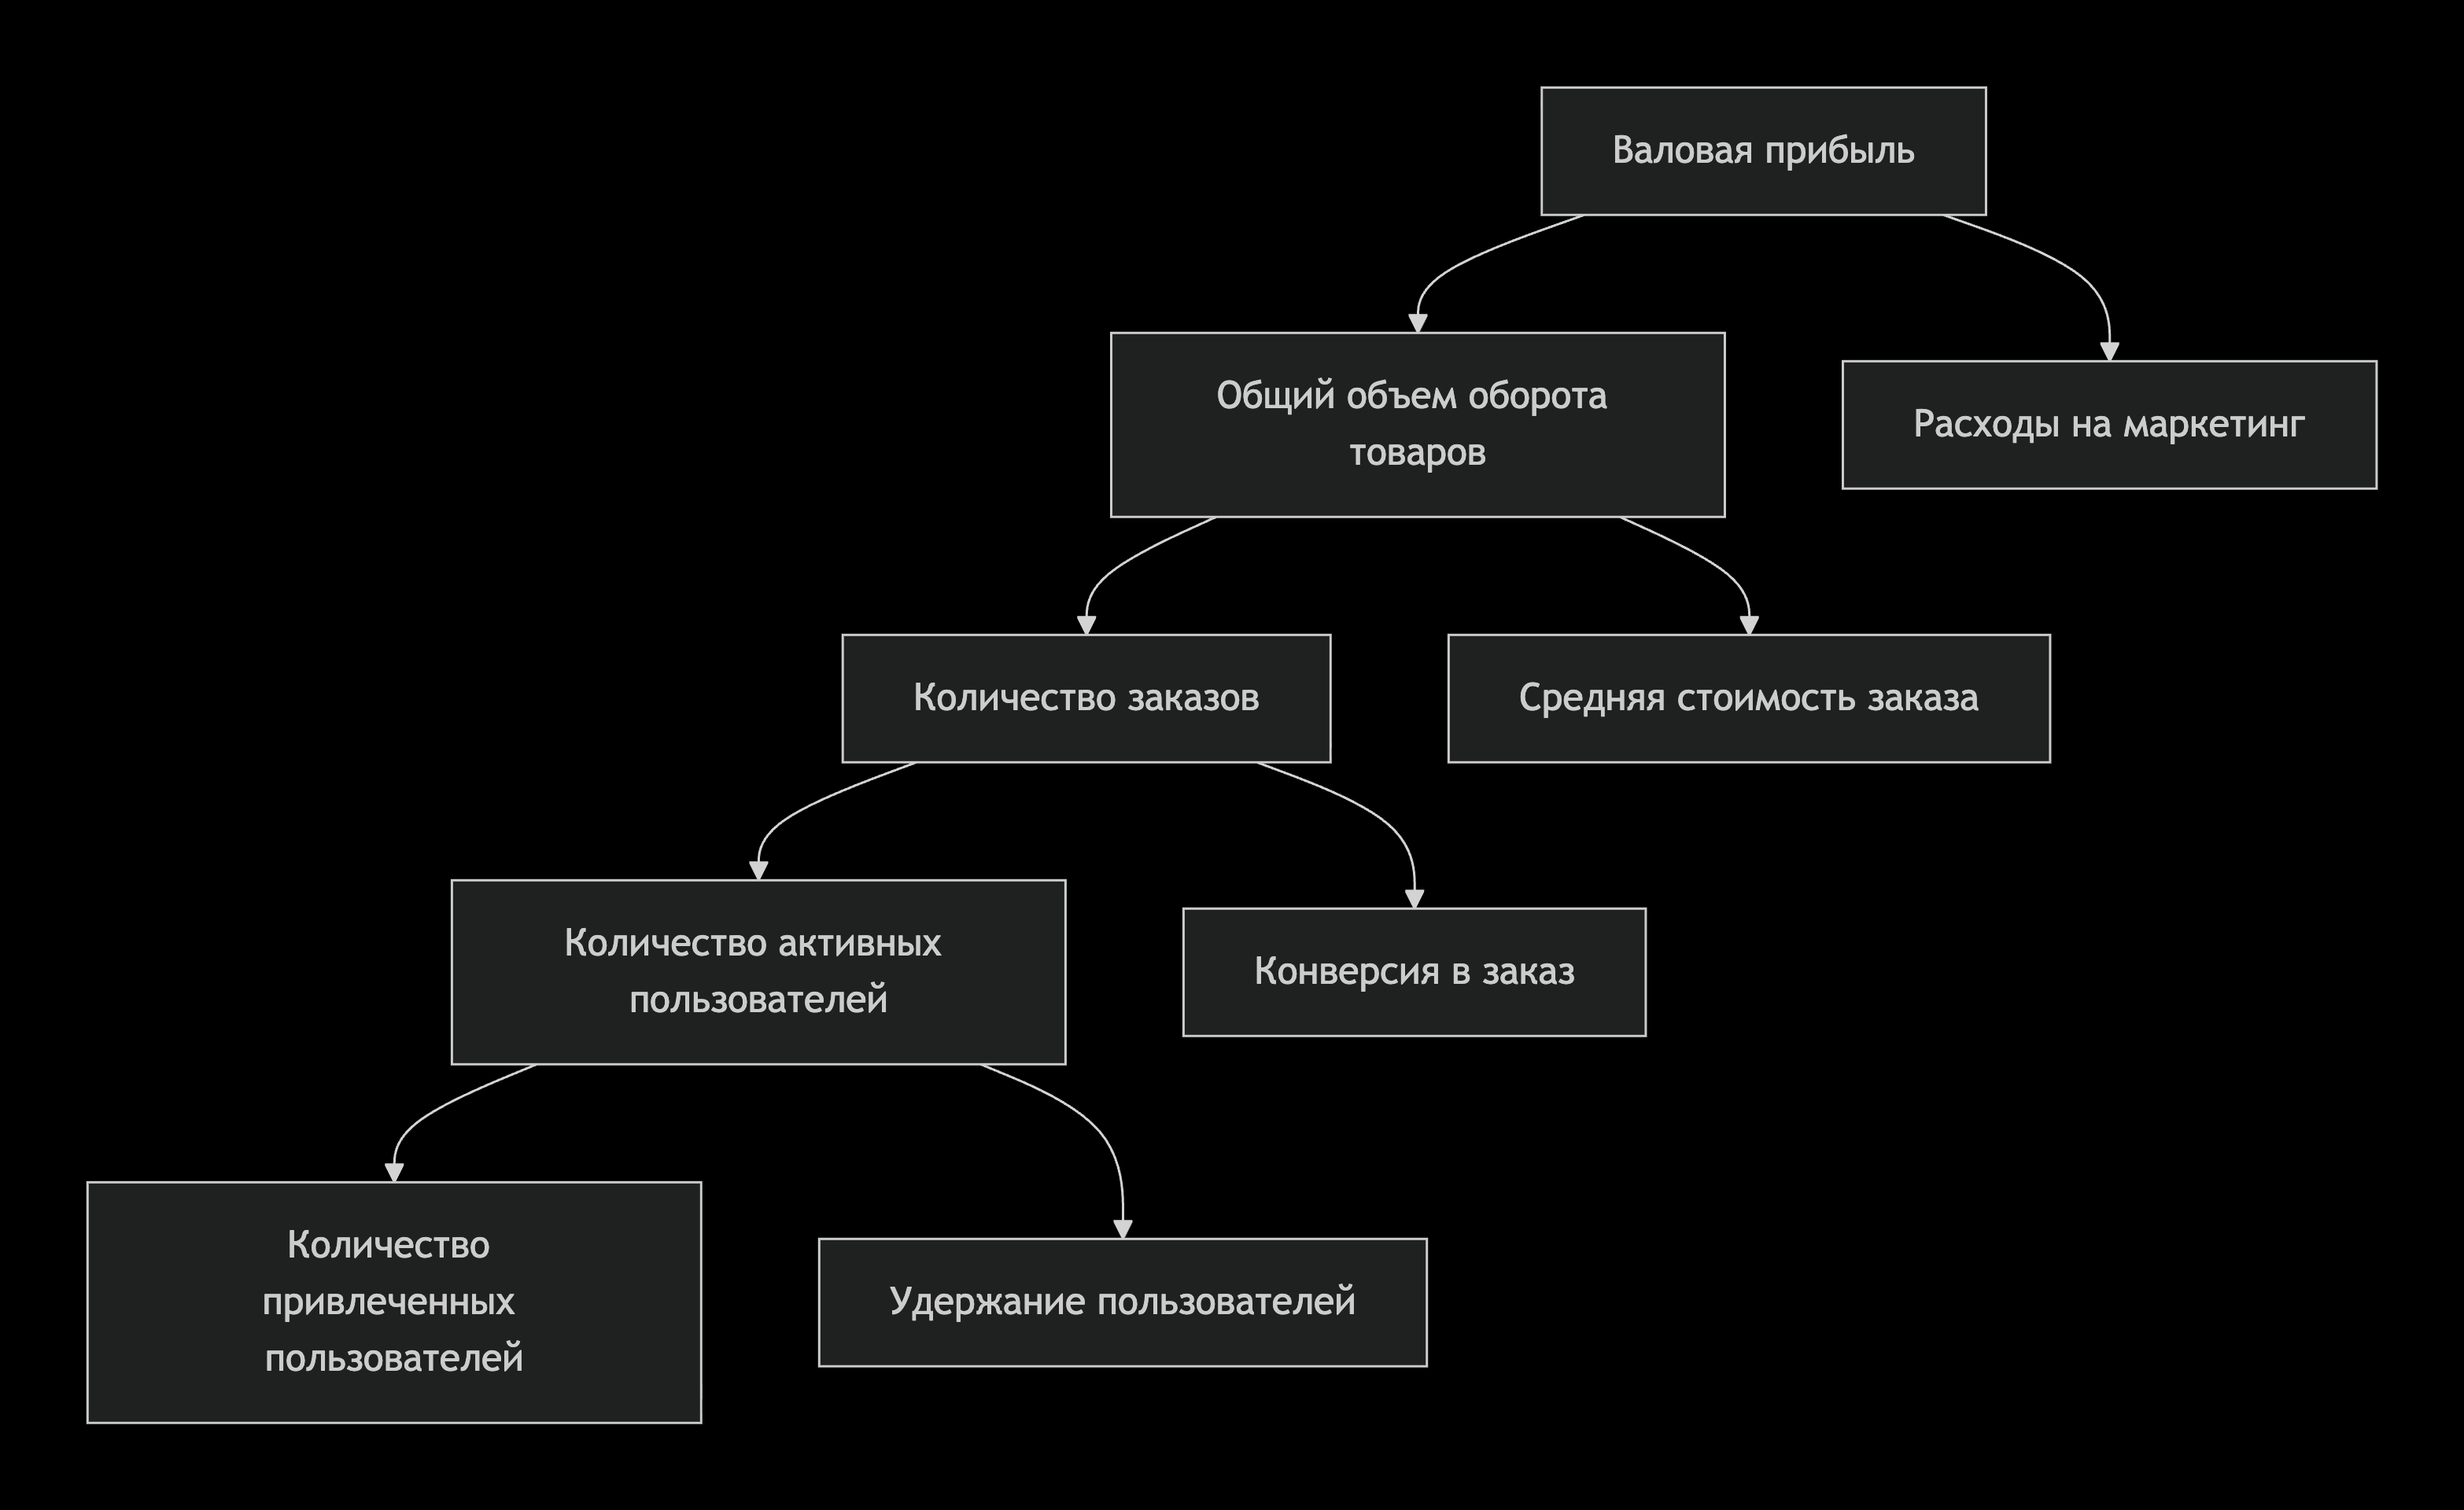

### Описание данных

1. Таблица **Users**
- `user_id` — уникальный идентификатор пользователя
- `registration_date` — дата регистрации пользователя
- `age` — возраст
- `gender` — пол (M, F)
- `region` — регион
- `buyer_segment` — сегмент покупателя
- `acq_channel` — канал привлечения
- `cohort_week` — неделя регистрации
- `cohort_month` — месяц регистрации

2. Таблица **Orders**
- `order_id` — уникальный идентификатор заказа
- `user_id` — идентификатор пользователя, который сделал заказ (внешний ключ на пользователя)
- `order_date` — дата и время оформления заказа
- `product_id` — уникальный идентификатор товара, который был куплен
- `product_name` - наименование продукта
- `category_name` - наименование категории продукта
- `quantity` — количество единиц товара в заказе
- `unit_price` — цена за одну единицу товара на момент заказа
- `total_price` — общая стоимость позиции в заказе (quantity × unit_price)
- `order_week` — неделя заказа
- `order_month` — месяц заказа

3. Таблица **Events**
- `event_id` — уникальный идентификатор события
- `user_id` — уникальный идентификатор пользователя
- `timestamp` — время и дата события
- `event_type` — тип события (например, вход пользователя, просмотр страницы, просмотр товара, добавление в корзину)
- `product_id` — идентификатор продукта, к которому относится событие (если применимо)
- `event_params` — JSON-поле с дополнительными параметрами события. Некоторые дополнительные параметры:
- `device` — тип устройства, на котором произошло событие (например, desktop, mobile, tablet)
- `os` — операционная система (macOS, Windows, iOS, Android и другие)
- `event_week` — неделя события
- `event_month` — месяц события

4. Таблица **campaign_costs** 
- `acq_channel` — канал привлечения (например, Affiliate, Targeted Ads, Email Marketing и др.)
- `spend_month` — месяц, в который был потрачен бюджет, YYYY-MM (отражает период, в котором были привлечены пользователи)
- `budget` — маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце

### ER-диаграмма — для удобства дальнейшей работы

#### Описание:

Таблица **Users**:
- PK: `user_id`
- поле: `acq_channel`
- Связи: 
    - с **Orders** (один ко многим)
    - с **Events** (один ко многим)
    - в **Campaigns** есть столбец `acq_channel`, содержат одинаковый набор значений

Таблица **Campaigns**:
- PK: Отсутствует (!!!)
- поле: `acq_channel`
- Связи: 
    - в таблице **Users** есть столбец с таким же набором значений

Таблица **Orders**:
- PK: `order_id`
- FK: `user_id` (ссылается на **Users**.`user_id`)
- FK: `product_id` (ссылается на **Product_dict**.`product_id`)
- Связи: 
    - с **Users** (многие к одному)
    - с **Product_dict** (многие к одному)

Таблица **Product_dict**:
- PK: product_id
- Связи: 
    - с **Orders** (один ко многим)
    - с **Events** (один ко многим)

Таблица **Events**:
- PK: `event_id`
- FK: `user_id` (ссылается на **Users**.`user_id`)
- FK: `product_id` (ссылается на **Product_dict**.`product_id`)
- Связи: 
    - с **Users** (многие к одному) 
    - с **Product_dict** (многие к одному)

#### Визуализация

### Импорт библиотек

In [1]:
# установка необходимых библиотек
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
def display_with_heading(heading, data):
    '''
    Функция для красивого отображения
    датафреймов с заголовком сверху
    
    heading — (str) — заголовок
    data — (pandas dataframe) — dataframe
    '''
    
    print(f'{heading}:')
    display(data)

### 1.1 Загрузка и предобработка датасетов, предварительное изучение данных

#### Датафрейм Users

In [4]:
try:
    users = pd.read_csv(
        'datasets/pa_marketplace_users.csv',
        parse_dates=[
            'registration_date', 'cohort_month', 
            'cohort_week',
        ]
    )
    
except:
    users = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_marketplace_users.csv',
        parse_dates=[
            'registration_date', 'cohort_month', 
            'cohort_week',
        ]
    )

display_with_heading(
    'Датафрейм users, первые 5 строк',
    users.head()
)

print('Информация о датафрейме users:\n')
users.info()

# изучим диапазоны значений
# численных столбцов
with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        '\nДиапазон столбцов с датами и численными значениями',
        users.describe(exclude=object).loc[['min', 'max']]
    )

# изучим уникальные значения
# категориальных столбцов
category_columns_users = [
    'gender', 'region', 
    'acq_channel', 'buyer_segment',
]

for column in category_columns_users:
    display_with_heading(
        f'Уникальные значения столбца {column}',
        list(users[column].unique())
    )
    print('\n')

# посмотрим на наличие дубликатов
print(
    'Кол-во полных дубликатов в датафрейме:',
    users.duplicated().sum()
)

Датафрейм users, первые 5 строк:


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


Информация о датафрейме users:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB

Диапазон столбцов с датами и численными значениями:


,user_id,registration_date,age,cohort_week,cohort_month
min,1.00,2024-01-01 00:07:00,18.00,2024-01-01 00:00:00,2024-01-01 00:00:00
max,44963.00,2024-12-31 23:44:00,70.00,2024-12-30 00:00:00,2024-12-01 00:00:00


Уникальные значения столбца gender:


...



Уникальные значения столбца acq_channel:


['Google Ads', 'Email Marketing', 'Affiliate', 'SEO', 'Social Media', 'TikTok']



Уникальные значения столбца buyer_segment:


['regular', 'rare', 'one_time', 'medium']



Кол-во полных дубликатов в датафрейме: 0


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>

    
💡 Верное решение использовать параметр `parse_dates` при загрузке CSV-файлов. Это автоматически преобразует столбцы с датами в формат datetime, что избавит от необходимости делать это позже.
    


#### Промежуточный вывод по датафрейму users: 
- данные выгружены верно (присутствуют все столбцы, значения соответствуют смыслу столбцов)
- типы данных подходящие
- пропусков нет
- диапазоны значений нормальные (минимальный возраст — 18, максимальный — 70)
- в категориальных столбцах неявных дубликатов нет
- полных дубликатов в датафрейме нет

#### Датафрейм Orders

In [5]:
try:
    orders = pd.read_csv(
        'datasets/pa_marketplace_orders.csv',
        parse_dates=[
            'order_date', 'order_month', 
            'order_week',
        ]
    )
    
except:
    orders = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv',
        parse_dates=[
            'order_date', 'order_month', 
            'order_week',
        ]
    )
    
display_with_heading(
    'Датафрейм orders, первые 5 строк',
    orders.head()
)

print('Информация о датафрейме orders:\n')
orders.info()

# изучим диапазоны значений
# численных столбцов
with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        '\nДиапазон столбцов с датами и численными значениями',
        orders.describe(exclude=object).loc[['min', 'max']]
    )

# изучим кол-во наименований категорий
print(
    '\nКол-во уникальных наименований категорий товаров:',
    orders['category_name'].nunique()
)

# посмотрим на наличие дубликатов
print(
    '\nКол-во полных дубликатов в датафрейме:',
    orders.duplicated().sum()
)

Датафрейм orders, первые 5 строк:


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


Информация о датафрейме orders:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB

Диапазон столбцов с датами и численными значениями:


,order_id,user_id,order_date,quantity,unit_price,total_price,order_week,order_month
min,1.00,3.00,2024-01-01 08:03:45,1.00,339.00,339.00,2024-01-01 00:00:00,2024-01-01 00:00:00
max,31791.00,44906.00,2024-12-31 23:00:53,3.00,63932.38,191797.14,2024-12-30 00:00:00,2024-12-01 00:00:00



Кол-во уникальных наименований категорий товаров: 25

Кол-во полных дубликатов в датафрейме: 0


#### Промежуточный вывод по датафрейму orders:
- данные выгружены верно (присутствуют все столбцы, значения соответствуют смыслу столбцов)
- типы данных подходящие
- пропусков нет
- диапазоны значений нормальные (кол-во единиц товара от 1 до 3, стоимость единицы товара от ~350 до ~64 000, общая стоимость позиции в заказе до 200 000)
- полных дубликатов в датафрейме нет

#### Датафрейм Events

In [6]:
try:
    events = pd.read_csv(
        'datasets/pa_marketplace_events.csv',
        parse_dates=[
            'event_date', 'event_month', 
            'event_week',
        ]
    )
    
except:
    events = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_marketplace_events.csv',
        parse_dates=[
            'event_date', 'event_month', 
            'event_week',
        ]
    )

display_with_heading(
    'Датафрейм events, первые 5 строк',
    events.head()
)

print('Информация о датафрейме events:\n')
events.info()

# изучим диапазоны значений
# численных столбцов
with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        '\nДиапазон столбцов с датами и численными значениями',
        events.describe(exclude=object).loc[['min', 'max']]
    )

# изучим уникальные значения
# категориальных столбцов
category_columns_events = [
    'event_type', 'os', 
    'device', 
]

for column in category_columns_events:
    display_with_heading(
        f'Уникальные значения столбца {column}',
        list(events[column].unique())
    )
    print('\n')

# посмотрим на наличие дубликатов
print(
    'Кол-во полных дубликатов в датафрейме:',
    events.duplicated().sum()
)

Датафрейм events, первые 5 строк:


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


Информация о датафрейме events:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[ns]
 3   event_type    785859 non-null  object        
 4   os            785859 non-null  object        
 5   device        785859 non-null  object        
 6   product_name  385740 non-null  object        
 7   event_week    785859 non-null  datetime64[ns]
 8   event_month   785859 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 54.0+ MB

Диапазон столбцов с датами и численными значениями:


,event_id,user_id,event_date,event_week,event_month
min,1.00,2.00,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:00:00
max,839961.00,44960.00,2024-12-31 00:00:00,2024-12-30 00:00:00,2024-12-01 00:00:00


Уникальные значения столбца event_type:


...



Уникальные значения столбца os:


['iOS', 'Windows', 'macOS', 'Android']



Уникальные значения столбца device:


['mobile', 'desktop', 'tablet']



Кол-во полных дубликатов в датафрейме: 0


#### Промежуточный вывод по датафрейму events: 
- данные выгружены верно (присутствуют все столбцы, значения соответствуют смыслу столбцов)
- типы данных подходящие
- есть пропуски в столбце `product_name`, но они объяснимы (не для всех типов события  можно указать наименование продукта)
- диапазоны значений нормальные
- в дальнейшем необходимо будет установить порядок пользовательских событий
- неявных дубликатов среди категориальных значений нет
- полных дубликатов нет

#### Датафрейм campaign_costs

In [7]:
try:
    campaign_costs = pd.read_csv(
        'datasets/pa_marketplace_campaign_costs.csv',
        parse_dates=[
            'spend_month',
        ],
        index_col=0,
    ).rename_axis(None, axis=0)
    
except:
    campaign_costs = pd.read_csv(
        'https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv',
        parse_dates=[
            'spend_month', 
        ],
        index_col=0,
    ).rename_axis(None, axis=0)

display_with_heading(
    'Датафрейм campaign_costs, первые 5 строк',
    campaign_costs.head()
)

print('Информация о датафрейме campaign_costs:\n')
campaign_costs.info()

# изучим диапазоны значений
# численных столбцов
with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        '\nДиапазон столбцов с датами и численными значениями',
        campaign_costs.describe(exclude=object).loc[['min', 'max']]
    )

# изучим уникальные значения
# категориальных столбцов
display_with_heading(
    'Каналы привлечения',
    campaign_costs['acq_channel'].unique()
)

# посмотрим на наличие дубликатов
print(
    '\nКол-во полных дубликатов в датафрейме:',
    campaign_costs.duplicated().sum()
)

Датафрейм campaign_costs, первые 5 строк:


,acq_channel,spend_month,budget
0,Affiliate,2024-01-01,179343.3875
1,Affiliate,2024-02-01,175488.4875
2,Affiliate,2024-03-01,164543.4750
3,Affiliate,2024-04-01,186869.9750
4,Affiliate,2024-05-01,166443.7750


Информация о датафрейме campaign_costs:

<class 'pandas.core.frame.DataFrame'>
Index: 88 entries, 0 to 87
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   acq_channel  88 non-null     object        
 1   spend_month  88 non-null     datetime64[ns]
 2   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 2.8+ KB

Диапазон столбцов с датами и численными значениями:


,spend_month,budget
min,2024-01-01 00:00:00,6674.10
max,2025-01-01 00:00:00,1533683.38


Каналы привлечения:


array(['Affiliate', 'Direct', 'Email Marketing', 'Social Media',
       'Google Ads', 'SEO', 'TikTok'], dtype=object)


Кол-во полных дубликатов в датафрейме: 0


#### Промежуточный вывод по датафрейму campaign_costs: 
- данные выгружены верно (присутствуют все столбцы); бюджет на месяц отображается с большей точностью, чем возможно (валюты позволяют точность до сотых максимум; так может получиться при делении, например, годового бюджета), это не критично
- типы данных подходящие
- пропусков нет
- диапазоны значений нормальные (минимальный месяный бюджет ~ 6 500, максимальный — ~ 1 500 000)
- есть данные за январь 2025 года; они не пригодятся, т.к. другие датафреймы содержат информацию только за 2024 год; поэтому удалим данные за январь 2025
- полных дубликатов нет


- уникальные значения столбца с каналами привлечения без неявных дубликатов; в данном датафрейме есть значение 'Direct', которое отсутствует в аналогичном столбце датафрейма **users**
  - Множество значений в таблице **Users**:
    1. *Google Ads*
    2. *Email Marketing*
    3. *Affiliate*
    4. *SEO*
    5. *Social Media*
    6. *TikTok*
    <br>
    
  - Множество значений в таблице **Campaigns**:
    1. *Google Ads*
    2. *Email Marketing*
    3. *Affiliate*
    4. *SEO*
    5. *Social Media*
    6. *TikTok* 
    7. *Direct* — значение, которого нет в пред. таблице

#### Оставим в campaign_costs только данные за 2024 год

In [8]:
# отфильтруем значения по дате,
# оставив только данные за 2024 год

campaign_costs = (
    campaign_costs[
        campaign_costs.spend_month.dt.year == 2024
    ]
)

# проверим результат
display_with_heading(
    'Диапазон значений столбца "spend_month" после фильтрации',
    campaign_costs.spend_month.describe().loc[['min', 'max']]
)

Диапазон значений столбца "spend_month" после фильтрации:


min    2024-01-01 00:00:00
max    2024-12-01 00:00:00
Name: spend_month, dtype: object

### 1.2 Вывод по предварительному изучению данных

- данные выгружены верно: столбцы присутствуют, значения соответствуют смыслу столцов и бизнес-контексту
- типы данных подходящие
- если в датафрейме есть пропуски, то они объяснимы
- диапазоны значений нормальные, временной диапазон совпадает для всех датафреймов 
- столбцы, содержащие категорийные данные, без неявных дубликатов
- полных дубликатов нет

Проблемная область:

У таблиц **Users** и **Campaigns** есть столбец `acq_channel`, в который занесены данные о канале привлечения. В таблице **Campaigns** значений на одно больше (есть канал *Direct*, которого нет в **Users**). Direct канал — метод прямого взаимодействия между компанией и клиентом, который позволяет рекламу и сообщения направлять напрямую без посредников, т.к. данные по этому каналу отсутствуют, сфокусируемся на др. каналах привлечения

### 2.1 Обзор ключевых метрик

#### 2.1.1 Валовая прибыль, общий объем оборота и маркетинговые расходы помесячно

Прибыль = Общий объем оборота товаров * Комиссия — Маркетинговые расходы

Поэтому рассчитаем по месяцам:
- общий объем оборота товаров
- общие маркетинговые расходы

Затем по формуле определим прибыль помесячно

In [9]:
campaign_costs_monthly = (
    campaign_costs
        .groupby('spend_month')
        .agg(total_camp_costs=('budget', 'sum'))
        .reset_index(names=['month'])
)

total_order_value_monthly = (
    orders
        .groupby('order_month')
        .agg(total_order_value=('total_price', 'sum'))
        .reset_index(names=['month'])
)

income_monthly = pd.merge(
    campaign_costs_monthly,
    total_order_value_monthly,
    how='inner',
    on='month'
)

income_monthly['income'] = (
    0.05 * income_monthly['total_order_value']
    - income_monthly['total_camp_costs']
)

with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        'Прибыль по месяцам',
        income_monthly
    )

Прибыль по месяцам:


,month,total_camp_costs,total_order_value,income
0,2024-01-01,1177456.97,12977800.53,-528566.94
1,2024-02-01,1061385.93,25931140.19,235171.08
2,2024-03-01,1167680.37,38814995.89,773069.42
3,2024-04-01,1147739.92,42856767.90,995098.48
4,2024-05-01,1225322.28,49575162.02,1253435.82
5,2024-06-01,1130439.77,42120237.13,975572.09
6,2024-07-01,1776446.60,48930709.06,670088.85
7,2024-08-01,1811677.75,49316047.93,654124.64
8,2024-09-01,1820718.83,38707333.94,114647.87
9,2024-10-01,1810802.57,34322165.12,-94694.31


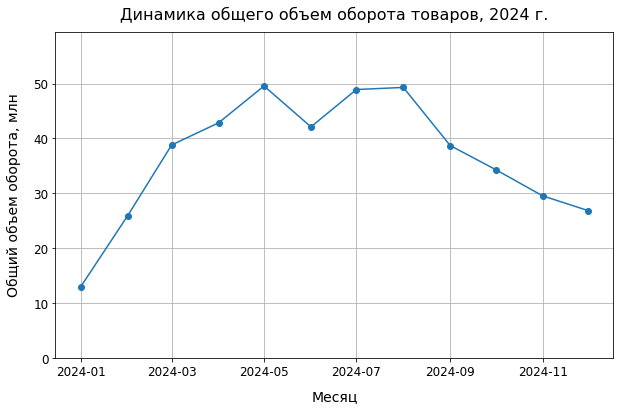

In [10]:
plt.figure(figsize=(10,6))

plt.plot(
    income_monthly['month'],
    income_monthly['total_order_value'] / 10**6,
    marker='o',
)

plt.title(
    'Динамика общего объем оборота товаров, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Общий объем оборота, млн',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)
plt.ylim((0, 1.2*max(income_monthly['total_order_value'])/10**6))
plt.grid()

plt.show()

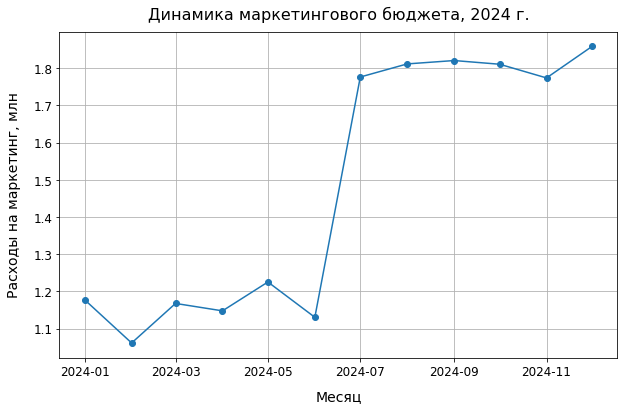

In [11]:
plt.figure(figsize=(10,6))

plt.plot(
    income_monthly['month'],
    income_monthly['total_camp_costs'] / 10**6,
    marker='o',
)

plt.title(
    'Динамика маркетингового бюджета, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Расходы на маркетинг, млн',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()

plt.show()

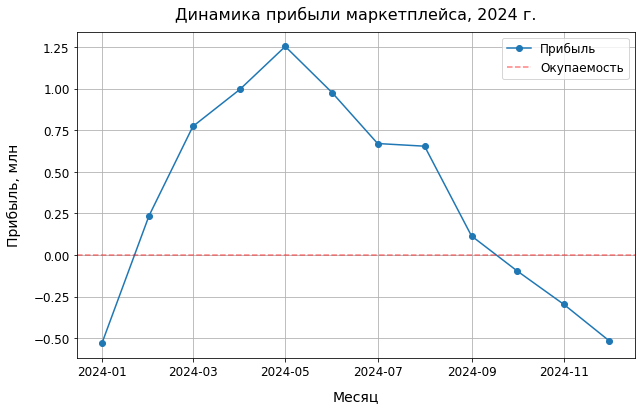

In [12]:
plt.figure(figsize=(10,6))

plt.plot(
    income_monthly['month'],
    income_monthly['income'] / 10**6,
    label='Прибыль',
    marker='o',
)

plt.axhline(
    0,
    linestyle='dashed',
    color='red',
    alpha=0.5,
    label='Окупаемость'
)

plt.title(
    'Динамика прибыли маркетплейса, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Прибыль, млн',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.legend(fontsize=12)

plt.show()

**Промежуточный вывод:**

Общий оборот товаров:
- с января по май — рост
- с июня по август — около стабильное значение
- с сентября по декабрь — падение

Маркетинговые расходы:
- с января по июнь - стабильное значение 
- с июля по декабрь - расходы на маркетинг увеличили примерно на 50%

Прибыль:
- с января по май — рост (вместе с общим оборотом товаров, маркетинговые расходы стабильны)
- с июня по декабрь — падение (сначала из-за роста расходов на маркетинг, затем к этому добавилось снижение общего оборота)
- **в январе бизнес был убыточным** (нормально на начальных этапах), **начиная с ноября бизнес стал убыточным**

Предположение (что было):
Общий оборот товаров и прибыль росли с начала 2024 года до мая включительно, в июне они просела на ~20% от значения в мае. Реакция (или совпадение по времени) — увеличение расходов на маркетинг в июле. Значения оборота товаров вернулись на уровень мая и оставались такими в течение 2 месяцев (июль, август), затем начали падать. Однако, прибыль падала все время с июля до конца 2024; 

**Что изучить при сегментации**: как именно были распределены дополнительные расходы на маркетинг

#### 2.1.2. Средняя стоимость заказа и кол-во заказов помесячно

Средняя стоимость заказа = общая стоимость заказа / кол-во заказов

Сгруппируем записи по идентификатору заказа и месяцу, затем рассчитаем кол-во заказов и среднюю стоимость заказа

In [13]:
order_values = (
    orders
        .groupby(['order_month', 'order_id'])
        .agg(order_value=('total_price', 'sum'))
        .reset_index()
)

metrics_level_2 = (
    order_values
        .groupby('order_month')
        .agg(
            total_orders=('order_id', 'nunique'),
            aov=('order_value', 'mean')
        )
        .reset_index()
)

with pd.option_context('display.float_format', '{:.2f}'.format):
    display_with_heading(
        'Средняя стоимость заказа и кол-во заказов по месяцам',
        metrics_level_2
    )

Средняя стоимость заказа и кол-во заказов по месяцам:


,order_month,total_orders,aov
0,2024-01-01,964,13462.45
1,2024-02-01,1917,13526.94
2,2024-03-01,2791,13907.20
3,2024-04-01,3124,13718.56
4,2024-05-01,3518,14091.86
5,2024-06-01,3058,13773.79
6,2024-07-01,3413,14336.57
7,2024-08-01,3393,14534.64
8,2024-09-01,2756,14044.75
9,2024-10-01,2478,13850.75


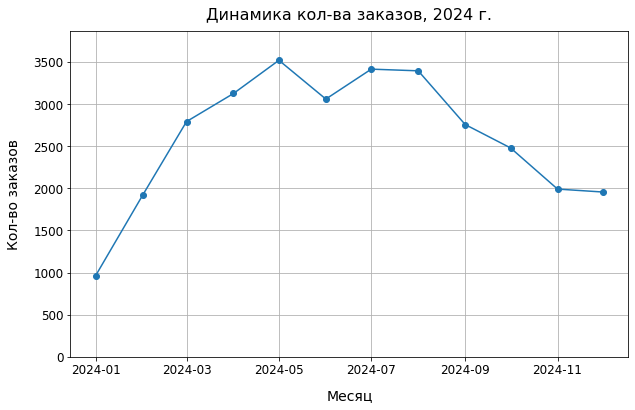

In [14]:
plt.figure(figsize=(10,6))

plt.plot(
    metrics_level_2['order_month'],
    metrics_level_2['total_orders'],
    marker='o',
)

plt.title(
    'Динамика кол-ва заказов, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Кол-во заказов',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.ylim((0, 1.1*max(metrics_level_2['total_orders'])))

plt.show()

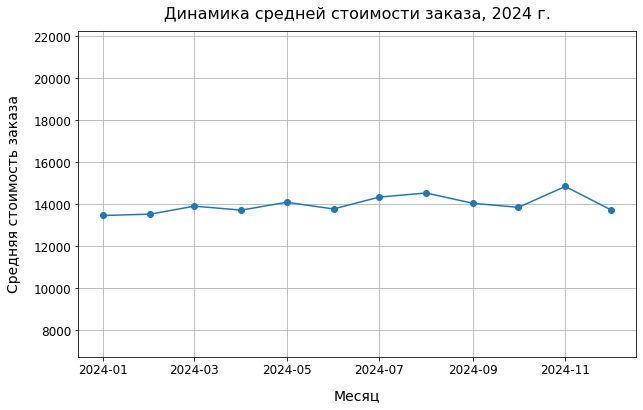

In [15]:
plt.figure(figsize=(10,6))

plt.plot(
    metrics_level_2['order_month'],
    metrics_level_2['aov'],
    marker='o',
)

plt.title(
    'Динамика средней стоимости заказа, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Средняя стоимость заказа',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.ylim(
    (
        0.5*min(metrics_level_2['aov']), 
        1.5*max(metrics_level_2['aov'])
    )
)

plt.show()

**Промежуточный вывод:**
- Средняя стоимость заказа стабильна на протяжении года
- Кол-во заказов коррелирует с общим объемом оборота, падает с сентября

#### 2.1.3. Кол-во активных пользователей (MAU)

Учитывая, что маркетплейс используется сравнительно редко, рассчитаем кол-во активных пользователей в месяц

In [16]:
active_users_monthly = (
    events
        .groupby('event_month')
        .agg(active_users=('user_id', 'nunique'))
        .reset_index()
)

display_with_heading(
    'Количество активных пользователей',
    active_users_monthly
)

Количество активных пользователей:


,event_month,active_users
0,2024-01-01,1149
1,2024-02-01,2162
2,2024-03-01,2844
3,2024-04-01,3059
4,2024-05-01,3310
5,2024-06-01,3174
6,2024-07-01,3481
7,2024-08-01,3861
8,2024-09-01,3744
9,2024-10-01,3581


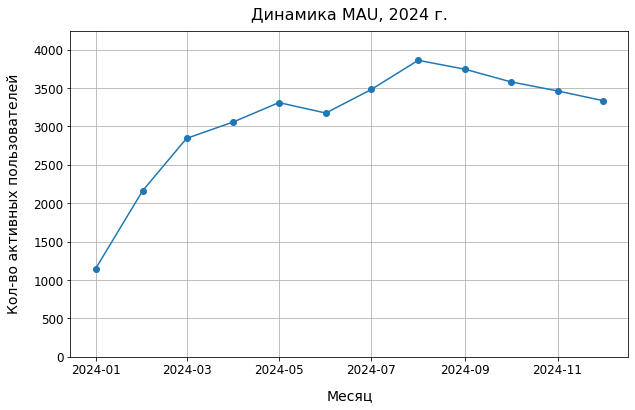

In [17]:
plt.figure(figsize=(10,6))

plt.plot(
    active_users_monthly['event_month'],
    active_users_monthly['active_users'],
    marker='o',
)

plt.title(
    'Динамика MAU, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Кол-во активных пользователей',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.ylim(
    (0, 1.1*max(active_users_monthly['active_users']))
)

plt.show()

**Промежуточный вывод:** кол-во активных пользователей начало падать в сентябре, это объясняет падение кол-ва заказов

#### 2.1.4. Конверсия из активного пользователя в покупателя

Любой активный пользователь видит объявления товаров на маркетплейсе, поэтому считаем конверсию из просмотра товара. Факт завершения процесса оформления заказа обычно сопровождается событием "checkout complete"

Просмотр товара — product_view, заказ — checkout_complete

In [18]:
viewers_monthly = (
    events[events['event_type'] == 'product_view']
        .groupby('event_month')
        .agg(viewers=('user_id', 'nunique'))
        .reset_index()
)


buyers_monthly = (
    events[events['event_type'] == 'checkout_complete']
        .groupby('event_month')
        .agg(buyers=('user_id', 'nunique'))
        .reset_index()
)

cr_to_order = pd.merge(
    viewers_monthly,
    buyers_monthly,
    how='inner',
    on='event_month'
)

cr_to_order['cr'] = 100 * (
    cr_to_order['buyers']
    / cr_to_order['viewers']
)

display_with_heading(
    'Конверсия из активного пользователя в покупателя',
    cr_to_order
)

Конверсия из активного пользователя в покупателя:


,event_month,viewers,buyers,cr
0,2024-01-01,1086,602,55.432781
1,2024-02-01,2048,1145,55.908203
2,2024-03-01,2662,1600,60.105184
3,2024-04-01,2870,1701,59.268293
4,2024-05-01,3107,1769,56.935951
5,2024-06-01,2943,1672,56.812776
6,2024-07-01,3281,1826,55.653764
7,2024-08-01,3644,1968,54.006586
8,2024-09-01,3554,1801,50.675295
9,2024-10-01,3412,1651,48.388042


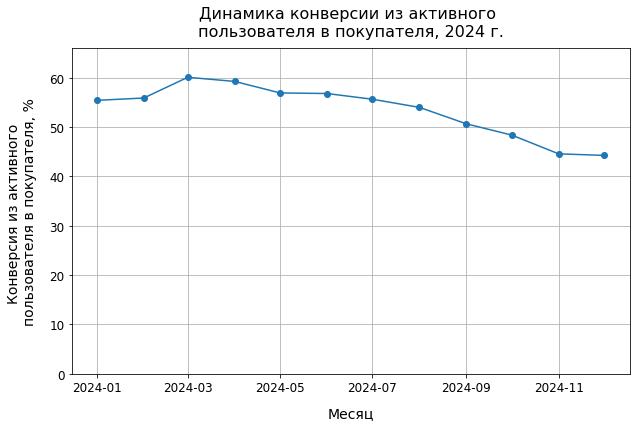

In [19]:
plt.figure(figsize=(10,6))

plt.plot(
    cr_to_order['event_month'],
    cr_to_order['cr'],
    marker='o',
)

plt.title(
    'Динамика конверсии из активного \nпользователя в покупателя, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Конверсия из активного \nпользователя в покупателя, %',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.ylim(
    (0, 1.1*max(cr_to_order['cr']))
)

plt.show()

**Промежуточный вывод:** конверсия начала постепенно падать в августе-сентябре, жо этого находилась на уровне 55-60%

#### 2.1.5. Кол-во привлеченных пользователей

Рассчитаем кол-во пользователей, привлеченных в месяц (факта регистрации в таблице с событиями нет, поэтому воспользуется таблицей с информацией о пользователях)

In [20]:
new_users_monthly = (
    users
        .groupby('cohort_month')
        .agg(new_users=('user_id', 'nunique'))
        .reset_index()
)

display_with_heading(
    'Кол-во привлеченных пользователей',
    new_users_monthly
)

Кол-во привлеченных пользователей:


,cohort_month,new_users
0,2024-01-01,2985
1,2024-02-01,2711
2,2024-03-01,2965
3,2024-04-01,2905
4,2024-05-01,3066
5,2024-06-01,2810
6,2024-07-01,4388
7,2024-08-01,4431
8,2024-09-01,4466
9,2024-10-01,4440


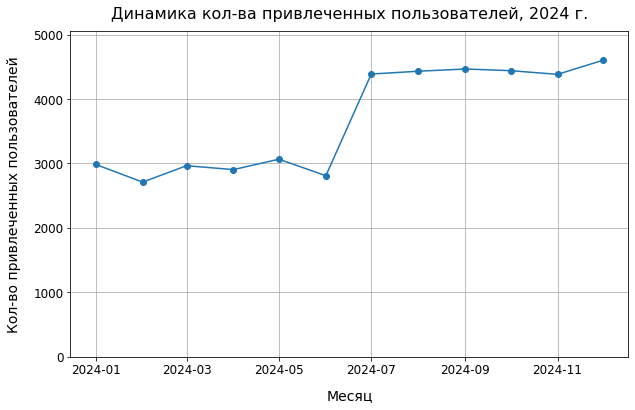

In [21]:
plt.figure(figsize=(10,6))

plt.plot(
    new_users_monthly['cohort_month'],
    new_users_monthly['new_users'],
    marker='o',
)

plt.title(
    'Динамика кол-ва привлеченных пользователей, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Кол-во привлеченных пользователей',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.ylim(
    (0, 1.1*max(new_users_monthly['new_users']))
)

plt.show()

**Промежуточный вывод:** кол-во привлеченных пользователей выросло одновременно с ростом расходов на маркетинговые кампании; рост пропорционален росту маркетинговых расходов (также +50%)

#### 2.1.6. Удержание пользователей

Учитывая, что в таблице **events** могут быть пользователи, которые зарегистрировались до 2024 года, отфильтруем ее (`user_id` должен быть в списке `user_id` пользователей, зарегистрировавшихся в 2024 году) 

Затем добавим в датафрейм с событиями информацию о месяце регистрации пользователей<br>
Посмотрим, в какие месяцы заходил на маркетплейс каждый из пользователей

In [22]:
# отфильтруем таблицу events
events_by_users_from_2024 = (
    events[events['user_id'].isin(users['user_id'])]
)

In [23]:
# объединим данные из таблицы events 
# и таблицы users
data_for_classic_retention = pd.merge(
    events_by_users_from_2024[['user_id', 'event_month']],
    users[['user_id', 'cohort_month']],
    how='inner',
    on='user_id'
)

# т.к. смотрим, возвращался ли пользователь
# в конкретный месяц, удалим полные дубликаты
data_for_classic_retention.drop_duplicates(inplace=True, ignore_index=True)

display_with_heading(
    'Начало таблицы с информацией о посещениях маркетплейса пользователями',
    data_for_classic_retention
        .sort_values(
            [
                'cohort_month', 
                'user_id', 
                'event_month'
            ])
        .head(10)
)

Начало таблицы с информацией о посещениях маркетплейса пользователями:


,user_id,event_month,cohort_month
20,2,2024-01-01,2024-01-01
21,2,2024-02-01,2024-01-01
11,3,2024-01-01,2024-01-01
12,3,2024-02-01,2024-01-01
411,5,2024-01-01,2024-01-01
412,5,2024-02-01,2024-01-01
413,5,2024-03-01,2024-01-01
87,6,2024-01-01,2024-01-01
88,6,2024-02-01,2024-01-01
89,6,2024-03-01,2024-01-01


In [24]:
# рассчитаем кол-во активных пользователей
# каждой когорты помесячно
data_for_classic_retention_gr = (
    data_for_classic_retention
        .groupby(['cohort_month', 'event_month'])
        .agg(total_users=('user_id', 'count'))
        .reset_index()
)

# добавим информацию о кол-ве пользователей,
# зарегистрировавшихся в этой когорте
data_for_classic_rr_plus_reg = pd.merge(
    data_for_classic_retention_gr,
    new_users_monthly,
    how='left',
    on='cohort_month'
)

# рассчитаем кол-во активных пользователей
# ежемесячно как долю от зарегистрировавшися
data_for_classic_rr_plus_reg['rr'] = 100 * (
    data_for_classic_rr_plus_reg['total_users']
    / data_for_classic_rr_plus_reg['new_users']
)

# также выведем номер месяца относительно
# месяца регистрации когорты
data_for_classic_rr_plus_reg['n_period'] = (
    1 + data_for_classic_rr_plus_reg['event_month'].dt.to_period('M').astype('int64')
    - data_for_classic_rr_plus_reg['cohort_month'].dt.to_period('M').astype('int64')
)

display_with_heading(
    'Датафрейм для визуализации удержания по когортам',
    data_for_classic_rr_plus_reg.head(12)
)

Датафрейм для визуализации удержания по когортам:


,cohort_month,event_month,total_users,new_users,rr,n_period
0,2024-01-01,2024-01-01,1102,2985,36.917923,1
1,2024-01-01,2024-02-01,1102,2985,36.917923,2
2,2024-01-01,2024-03-01,529,2985,17.721943,3
3,2024-01-01,2024-04-01,244,2985,8.174204,4
4,2024-01-01,2024-05-01,123,2985,4.120603,5
5,2024-01-01,2024-06-01,55,2985,1.842546,6
6,2024-01-01,2024-07-01,26,2985,0.871022,7
7,2024-01-01,2024-08-01,12,2985,0.402010,8
8,2024-01-01,2024-09-01,1,2985,0.033501,9
9,2024-01-01,2024-10-01,2,2985,0.067002,10


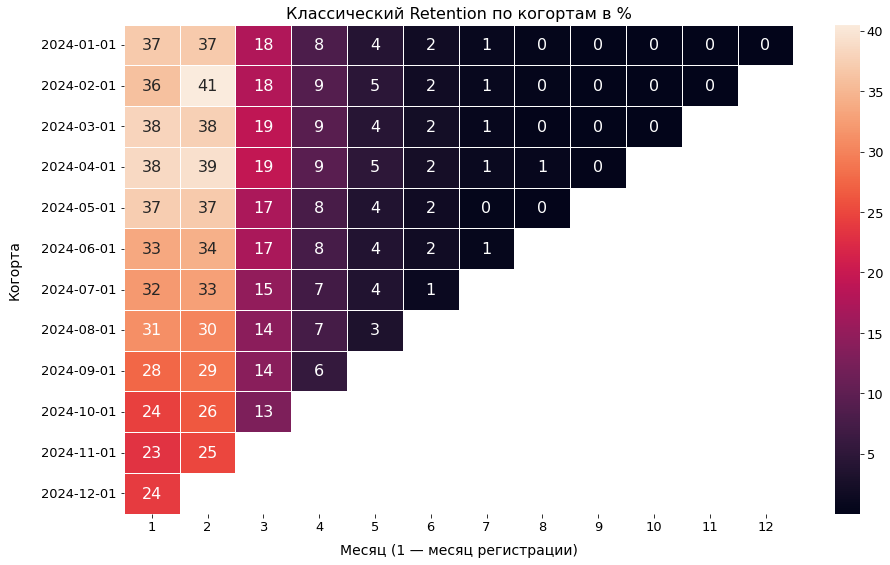

In [25]:
# перегруппируем данные так, чтобы для
# было удобно сравнивать удержание 
# по когортам помесячно
retention_data = (
    data_for_classic_rr_plus_reg.pivot(
        index='cohort_month',
        columns='n_period',
        values='rr'
    )
)

# визуализируем удержание
retention_data.index = pd.to_datetime(retention_data.index).strftime('%Y-%m-%d')

plt.subplots(figsize=(15,9))
ax = sns.heatmap(
    retention_data,
    annot=True,
    fmt=".0f",
    linewidth=0.5,
    annot_kws={"size": 16},
    cbar=True,
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)


plt.title('Классический Retention по когортам в %', fontsize=16)
plt.xlabel('Месяц (1 — месяц регистрации)', size=14, labelpad=10)
plt.ylabel('Когорта', size=14, labelpad=20)
plt.tick_params(labelsize=13)
plt.show()

**Промежуточный вывод:**  
- удержание падает от когорты к когорте начиная с июня 2024; т.е. на маркетплейс стала приходить менее заинтересованная аудитория
- снижающаяся конверсия может снизить эффект от увеличения кол-ва привлекаемых пользователей
- отметим также, что от регистрации на маркетплейсе до его использования доходит не более 40% пользователей. Возможно, регистрация дает какой-то бонус или происходит вместе с регистрацией на другом сервисе

Вероятно, бизнесу будет полезнее работать над удержанием существующих пользователей, а не над привлечением новых

###  2.2. Вывод по анализу ключевых метрик

**На декабрь 2024 года:**
- прибыль падает более полугода, с октября маркетплейс убыточен
- средняя стоимость заказа стабильна на протяжении года
- кол-во заказов падает с сентября
- кол-во активных пользователей падает с сентября
- конверсия из активного пользователя (заходит на маркетплейс, просматривает товары) в покупателя (дошел до завершения хотя бы одного заказа) падает с августа/сентября
- кол-во привлеченных пользователей стабильно, выросло в июле пропорционально росту расходов на маркетинг
- удержание пользователей падает с когорты июня включительно
- низкий процент пользователей переходит от регистрации на маркетплейсе к его использованию (не более 40%, на в декабрьской когорте — 24%)

**Дальнейшие действия:**
- т.к. падение ключевых метрик произошло после изменения расходов на маркетинг, необходимо в первую очередь посмотреть, как был распределен дополнительный бюджет, было ли перераспределение; 
- изучить подробнее удержание пользователей и конверсию в платящего пользователя (например, сегментировать или изучить вовлеченность/воронку событий до оформления заказа);

Более подробно:
- *Общий оборот товаров* рос с начала 2024 года до мая включительно, в июне он просел на ~20% от значения в мае
- Реакция (или совпадение по времени) — увеличение *расходов на маркетинг* в июле. Значения *общего оборота товаров* вернулись на уровень мая и оставались такими в течение 2 месяцев (июль, август), в сентябре снова начали падать
- *Прибыль* маркетплейса росла до мая 2024 включительно, затем падала; в сентябре наблюдался резкий спад; это объясняется снижением общего оборота товаров и одновременным увеличением роста расходов на маркетинг
- Динамика *кол-ва заказов* имеет тот же тренд, что и *общий оборот товаров*, средняя стоимость заказа стабильна; это объясняет падение общего оборота товаров
- *Кол-во активных пользователей* падает с сентября, как и *конверсия из активного пользователя в покупателя*; это объясняет падение кол-ва заказов
- *Удержание пользователей* падает с июня, что также объясняет падение кол-ва заказов

### 3.1 Оценка метрик монетизации и юнит-экономики

Будем оценивать значения помесячно, поэтому в качестве LTV возьмем средний доход на пользователя в месяц

#### 3.1.1 Расчет CAC 

CAC = marketing costs / new users

In [26]:
cac_data = pd.merge(
    new_users_monthly,
    income_monthly[['month', 'total_camp_costs']],
    how='inner',
    left_on='cohort_month',
    right_on='month'
)

cac_data['cac'] = (
    cac_data['total_camp_costs']
    / cac_data['new_users']
)

with pd.option_context('display.float_format', '{:.1f}'.format):
    display_with_heading(
        'Стоимость привлечения пользователя',
        cac_data[['month', 'cac']]
    )

Стоимость привлечения пользователя:


,month,cac
0,2024-01-01,394.5
1,2024-02-01,391.5
2,2024-03-01,393.8
3,2024-04-01,395.1
4,2024-05-01,399.6
5,2024-06-01,402.3
6,2024-07-01,404.8
7,2024-08-01,408.9
8,2024-09-01,407.7
9,2024-10-01,407.8


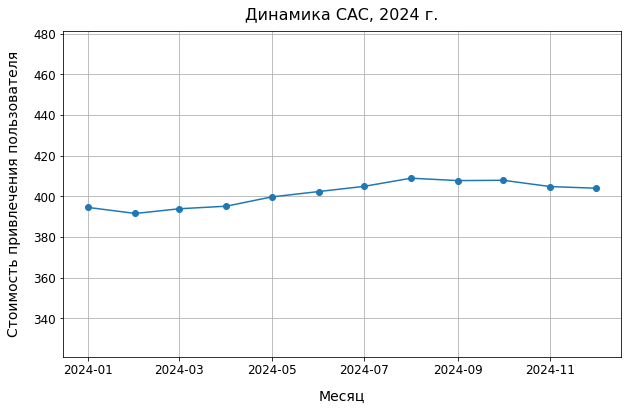

In [27]:
plt.figure(figsize=(10,6))

plt.plot(
    cac_data['month'],
    cac_data['cac'],
    marker='o',
)

plt.title(
    'Динамика CAC, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Стоимость привлечения пользователя',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.ylim(
    (
        0.8*cac_data['cac'].mean(), 
        1.2*cac_data['cac'].mean()
    )
)

plt.show()

**Промежуточный вывод:** 
- значение постоянно в течение года (разница между минимальным и максимальным значением менее 5%)
- стоимость привлечения пользователя изменилась незначительно после увеличения расходов на маркетинг 

#### 3.1.2. Расчет LTV (за 4 недели) 

Рассчитаем, сколько приносят пользователи каждой когорты за первый месяц на маркетплейсе;<br>
Т.к. CAC считали на пользователя, а не на платящего пользователя, тут поступим так же<br>
Выведем данные до ноября включительно, т.к. не для всех пользователей когорты декабря прошло 4 недели с недели регистрации

In [28]:
# объединим информация о заказах
# с информацией о неделе и месяце
# регистрации пользователей
orders_users = pd.merge(
    orders,
    users[['user_id', 'cohort_week', 'cohort_month']],
    how='left',
    on='user_id'
)

# выведем номер недели от недели
# регистрации для каждого заказа
orders_users['n_period'] = (
    orders_users['order_week'].dt.to_period('W').astype('int64')
    - orders_users['cohort_week'].dt.to_period('W').astype('int64')
)

# при расчете ценности клиента будем
# учитывать его заказы за первые 4 недели,
# сгруппируем по месяцу регистрации
first_month_orders_value_by_cohorts = (
    orders_users[orders_users['n_period'] < 4]
        .groupby('cohort_month')
        .agg(total_order_value=('total_price', 'sum'))
        .reset_index()
)

first_month_orders_value_by_cohorts['income_before_mark'] = (
    0.05 * first_month_orders_value_by_cohorts['total_order_value']
)

# рассчитаем LTV, разделив общую
# стоимость заказов каждой когорты
# на кол-во зарегистрированных пользователей
# в каждой когорте
ltv_data = pd.merge(
    new_users_monthly,
    first_month_orders_value_by_cohorts[['cohort_month', 'income_before_mark']],
    how='inner',
    on='cohort_month'
)

ltv_data['ltv'] = (
    ltv_data['income_before_mark']
    / ltv_data['new_users']
)

with pd.option_context('display.float_format', '{:.1f}'.format):
    display_with_heading(
        'Ценность привлеченного пользователя',
        ltv_data[['cohort_month', 'ltv']][:-1]
    )

Ценность привлеченного пользователя:


,cohort_month,ltv
0,2024-01-01,318.7
1,2024-02-01,345.5
2,2024-03-01,342.7
3,2024-04-01,401.1
4,2024-05-01,351.4
5,2024-06-01,305.7
6,2024-07-01,262.6
7,2024-08-01,202.2
8,2024-09-01,167.5
9,2024-10-01,132.3


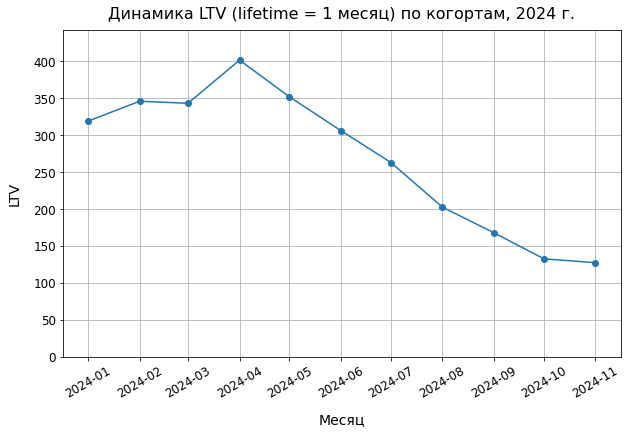

In [29]:
plt.figure(figsize=(10,6))

plt.plot(
    ltv_data['cohort_month'][:-1],
    ltv_data['ltv'][:-1],
    marker='o',
)

plt.title(
    'Динамика LTV (lifetime = 1 месяц) по когортам, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'LTV',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.ylim(
    (
        0, 
        1.1*ltv_data['ltv'].max()
    )
)
plt.xticks(rotation=30)

plt.show()

**Промежуточный вывод:** LTV (lifetime = 1 месяц) рос до апреля включительно; далее снижался с примерно постоянной скоростью 

#### 3.1.3. Расчет ROI за (4 недели)

Т.к. в качестве LTV взяли ценность привлеченного клиента за первый месяц, рассчитаем возврат инвестиций за первый месяц по когортам

In [30]:
roi_data = pd.merge(
    cac_data[['month', 'cac']],
    ltv_data[['cohort_month', 'ltv']],
    how='inner',
    left_on='month',
    right_on='cohort_month'
)

roi_data['roi_month'] = 100 * (roi_data['ltv'] - roi_data['cac']) / roi_data['cac']

display_with_heading(
    'Возврат инвестиций (%)',
    roi_data[['month', 'roi_month']]
)

Возврат инвестиций (%):


,month,roi_month
0,2024-01-01,-19.203315
1,2024-02-01,-11.754977
2,2024-03-01,-12.979482
3,2024-04-01,1.532856
4,2024-05-01,-12.067419
5,2024-06-01,-24.019044
6,2024-07-01,-35.139014
7,2024-08-01,-50.549371
8,2024-09-01,-58.925235
9,2024-10-01,-67.555135


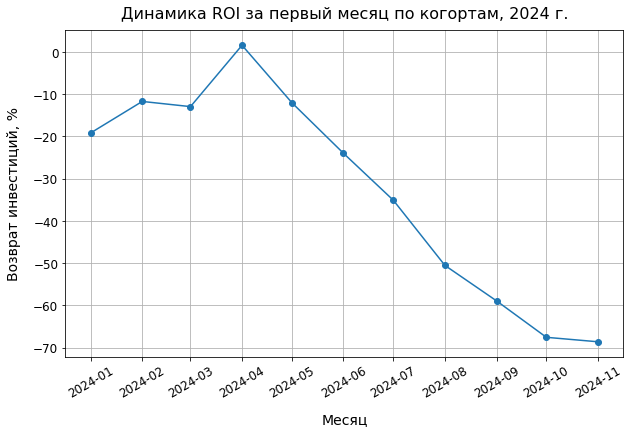

In [31]:
plt.figure(figsize=(10,6))

plt.plot(
    roi_data['month'][:-1],
    roi_data['roi_month'][:-1],
    marker='o',
)

plt.title(
    'Динамика ROI за первый месяц по когортам, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Возврат инвестиций, %',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.xticks(rotation=30)

plt.show()

**Промежуточный вывод:** возврат инвестиций за первый месяц рос до апреля включительно (в апреле когорта окупалась уже к первому месяцу), затем падал до конца года; в июне ROI был ниже значения в январе

Дополнительно изучим ROI по месяцам по когортам, т.к. нам неизвестен горизон событий

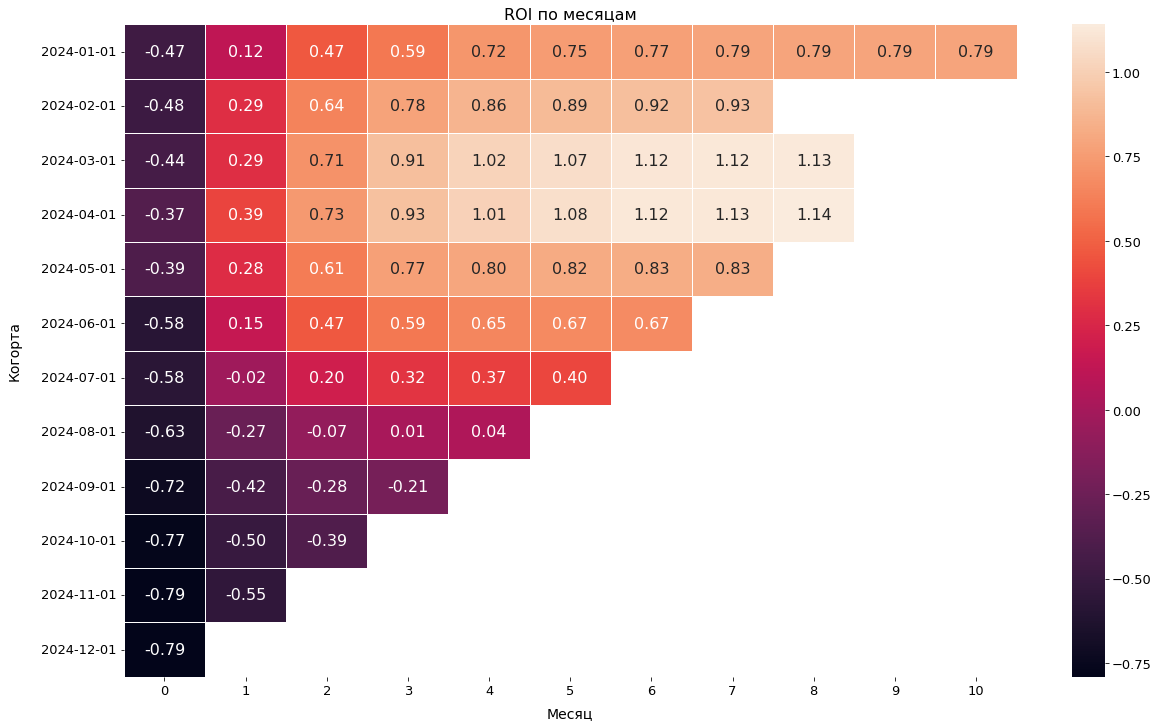

In [32]:
orders_users['n_month'] = (
    orders_users['order_month'].dt.to_period('M').astype('int64')
    - orders_users['cohort_month'].dt.to_period('M').astype('int64')
)

orders_users_gr_for_roi = orders_users.groupby(['cohort_month', 'n_month']).agg(income=('total_price', 'sum')).reset_index()

orders_users_gr_for_roi['cumulative_income'] = (
    orders_users_gr_for_roi
        .groupby('cohort_month')
        ['income'].cumsum()
)

orders_users_gr_for_roi['cum_revenue'] = (
    0.05 * orders_users_gr_for_roi['cumulative_income']
)

orders_users_gr_for_roi = pd.merge(
    orders_users_gr_for_roi,
    cac_data[['month', 'cac']],
    how='left',
    left_on='cohort_month',
    right_on='month'
)

orders_users_gr_for_roi = pd.merge(
    orders_users_gr_for_roi,
    new_users_monthly,
    how='left',
    on='cohort_month'
)

orders_users_gr_for_roi['ltv'] = (
    orders_users_gr_for_roi['cum_revenue']
    / orders_users_gr_for_roi['new_users']
)

orders_users_gr_for_roi['roi'] = (
    orders_users_gr_for_roi['ltv'] 
    - orders_users_gr_for_roi['cac']
) / orders_users_gr_for_roi['cac']

orders_users_gr_for_roi_vis = (
    orders_users_gr_for_roi.pivot(
        index='cohort_month',
        columns='n_month',
        values='roi'
    )
)

# визуализируем 
orders_users_gr_for_roi_vis.index = (
    pd.to_datetime(orders_users_gr_for_roi_vis.index)
        .strftime('%Y-%m-%d')
)

plt.subplots(figsize=(20,12))

ax = sns.heatmap(
    orders_users_gr_for_roi_vis,
    annot=True,
    fmt=".2f",
    linewidth=0.5,
    annot_kws={"size": 16},
    cbar=True,
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)


plt.title('ROI по месяцам', fontsize=16)
plt.xlabel('Месяц', size=14, labelpad=10)
plt.ylabel('Когорта', size=14, labelpad=20)
plt.tick_params(labelsize=13)
plt.show()

#### 3.1.4. Расчет payback period, основываясь на данных за первый месяц

In [33]:
roi_data['payback_period_months'] = (
    roi_data['cac']
    / roi_data['ltv']
)

with pd.option_context('display.float_format', '{:.1f}'.format):
    display_with_heading(
        'Срок окупаемости когорты, мес.',
        roi_data[['month', 'payback_period_months']][:-1]
    )

Срок окупаемости когорты, мес.:


,month,payback_period_months
0,2024-01-01,1.2
1,2024-02-01,1.1
2,2024-03-01,1.1
3,2024-04-01,1.0
4,2024-05-01,1.1
5,2024-06-01,1.3
6,2024-07-01,1.5
7,2024-08-01,2.0
8,2024-09-01,2.4
9,2024-10-01,3.1


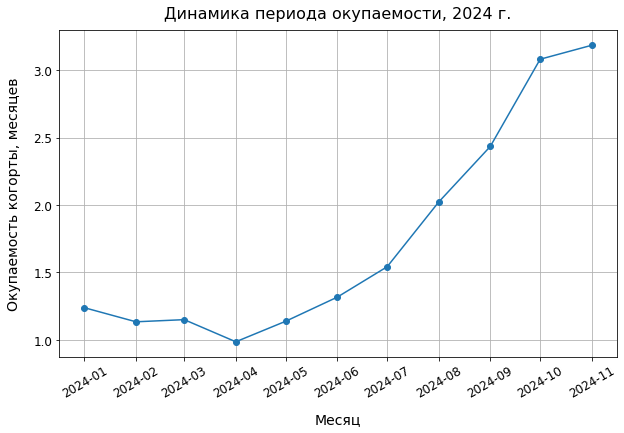

In [34]:
plt.figure(figsize=(10,6))

plt.plot(
    roi_data['month'][:-1],
    roi_data['payback_period_months'][:-1],
    marker='o',
)

plt.title(
    'Динамика периода окупаемости, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Окупаемость когорты, месяцев',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)

plt.grid()
plt.xticks(rotation=30)

plt.show()

**Промежуточный вывод:** период окупаемости изначально находился на уровне 1-1.5 месяцев; в июле значение превысило 1.5 месяца и продолжает расти

### 3.2 Вывод по оценке метрик монетизации и юнит-экономики

В данной секции исследовали экономику маркетплейса, взяв в качестве юнита пользователя: 
- Стоимость привлечения пользователя стабильна в течение года
- Ценность пользователя в первый месяц на маркетплейсе падает с когорты апреля; поэтому снижется возврат инвестиций и увеличивается срок окупаемости
- Срок окупаемости когорты ноября более 3-х месяцев, хотя в начале года значения достигали ~1 месяца

Ранее был рассчитан средний чек: он остается постоянным в течение года<br>

### 4.1 Поиск инсайтов, точек роста и сегментация

#### 4.1.1 Изучение перераспределения маркетингового бюджета

Первое, что заметили при изучении ключевых метрик — в июле были значительно (в 1.5 раза) увеличены расходы на маркетинг. Изучим, как были распределены дополнительные средства между каналами, т.к. после этого изменения началось ухудшение ключевых метрик

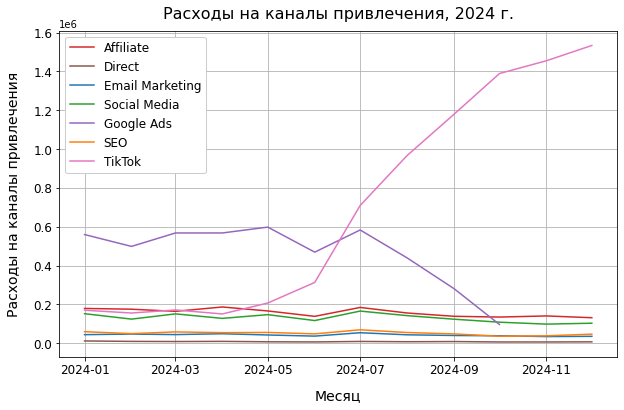

In [35]:
channel_hues = {
    "Affiliate": "tab:red", 
    "Direct": "tab:brown",
    "Email Marketing": "tab:blue", 
    "Social Media": "tab:green",
    "Google Ads": "tab:purple",
    "SEO": "tab:orange",
    "TikTok": "tab:pink",
}

# расходы на каналы по месяцам
plt.figure(figsize=(10,6))

sns.lineplot(
    data=campaign_costs, 
    x='spend_month', 
    y='budget', 
    hue='acq_channel',
    palette=channel_hues,
)

plt.title(
    'Расходы на каналы привлечения, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Расходы на каналы привлечения',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)
plt.legend(
    fontsize=12,
    framealpha=1,
)
plt.grid()
plt.show()

**Промежуточный вывод:** 
- в июне начали расти расходы на канал "TikTok"
- начиная с августа начали снижаться расходы на канал "Google Ads"
- асходы на другие маркетинговые каналы оставались стабильными в течение года

**Дальнейшие действия:**<br>
Можно предположить, что прирост пользователей произошел исключительно за счет канала "TikTok", проверим это

#### 4.1.2 Изучение притока пользователей по каналам

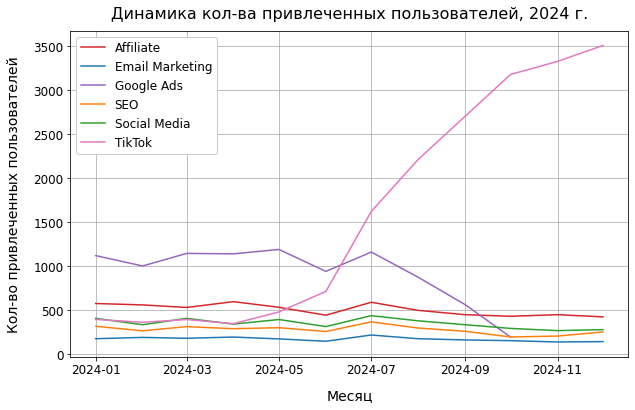

In [36]:
# новые пользователи по каналам
# по месяцам
new_users_monthly_ch = (
    users
        .groupby(['cohort_month', 'acq_channel'])
        .agg(new_users=('user_id', 'nunique'))
        .reset_index()
)

# визуализация
plt.figure(figsize=(10,6))

sns.lineplot(
    data=new_users_monthly_ch, 
    x='cohort_month', 
    y='new_users', 
    hue='acq_channel',
    palette=channel_hues
)

plt.title(
    'Динамика кол-ва привлеченных пользователей, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Кол-во привлеченных пользователей',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)
plt.legend(
    fontsize=12,
    framealpha=1,
)
plt.grid()
plt.show()

**Промежуточный вывод:** 
- прирост пользователей действительно произошел за счет канала TikTok
- кол-во пользователей, приходящих из канала Google Ads постепенно снижалось, с ноября с этим каналом перстали работать

**Дальнейшие действия:**<br>
Посмотрим на распределение платящих пользователей по каналам, возможно, пользователи, приходящие из канала TikTok совершают меньше заказов относительно пользователей из других каналов

#### 4.1.3 Изучение кол-ва платящих пользователей по каналам привлечения

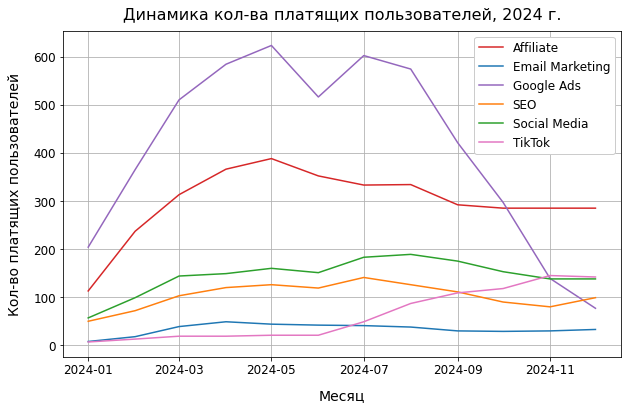

In [37]:
# добавим к информации о заказах
# информацию о канале привлечения
orders_users_ch = pd.merge(
    orders,
    users[['user_id', 'acq_channel']],
    how='left',
    on='user_id'
)

# сгруппируем по каналам привлечения
# и рассчитаем кол-во платящих пользователей
orders_users_ch_gr = (
    orders_users_ch
        .groupby(['acq_channel', 'order_month'])
        .agg(total_users=('user_id', 'nunique'))
        .reset_index()
)

# визуализация
plt.figure(figsize=(10,6))

sns.lineplot(
    data=orders_users_ch_gr, 
    x='order_month', 
    y='total_users', 
    hue='acq_channel',
    palette=channel_hues
)

plt.title(
    'Динамика кол-ва платящих пользователей, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Кол-во платящих пользователей',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)
plt.legend(
    fontsize=12,
    framealpha=1,
)
plt.grid()
plt.show()

**Промежуточный вывод:** 
- отказались от канала, который приводил наибольшее кол-во платящих пользователей (Google Ads)
- вложились в канал, из которого приходили наименее активные пользователи (TikTok). 
Т.е. по сути вложились не туда

Более подробно:
- В июне видна просадка по кол-ву пользователей, которые совершают заказы, пришедших из каналов Affiliate и Google Ads
- В сентябре видно сильное падение кол-ва пользователей, совершающих заказы, пришедших из Google Ads

Это совпадает со временем снижения общего объема оборота и общего числа активных пользователей 

#### 4.1.4 Изучение профилей пользователей из различных каналов

Посмотрим на то, какие пользователи (пол/возраст/регион) приходят из каждого из каналов. Возможно, где-то лучше настроен контекст

##### Различия по каналам по половому признаку

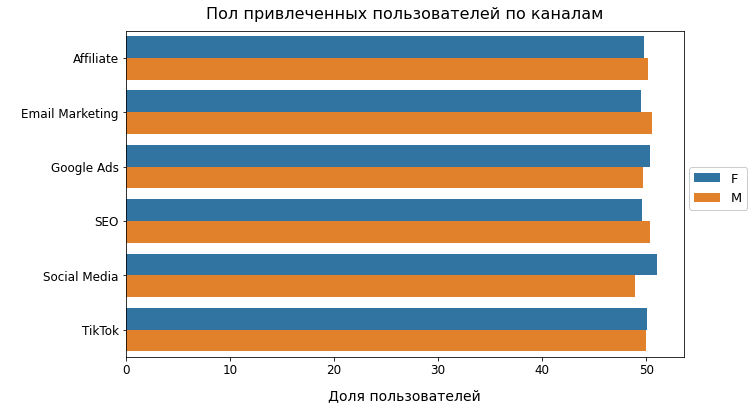

In [38]:
# кол-во привлеченных пользователей
# сегментация по полу
new_users_channel_gender = (
    users
        .groupby(['acq_channel', 'gender'])
        .agg(new_users=('user_id', 'nunique'))
        .reset_index()
)

# общее кол-во привлеченных пользователей
new_users_ch = (
    users
        .groupby(['acq_channel'])
        .agg(new_users_total=('user_id', 'nunique'))
        .reset_index()
)

# объединяем таблицы и считаем доли
new_users_channel_gender = pd.merge(
    new_users_channel_gender,
    new_users_ch,
    how='left',
    on='acq_channel'
)

new_users_channel_gender['share'] = 100 * (
    new_users_channel_gender['new_users']
    / new_users_channel_gender['new_users_total']
)

# визуализация
plt.figure(figsize=(10,6))

sns.barplot(
    data=new_users_channel_gender, 
    x="share", y="acq_channel", 
    hue="gender",
)

plt.title(
    'Пол привлеченных пользователей по каналам',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Доля пользователей',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    ' ',
)

plt.tick_params(
   labelsize=12 
)
plt.legend(
    fontsize=13,
    framealpha=1,
    loc=(1.01, 0.45)
)

plt.show()

**Промежуточный вывод:** различия по половому признаку между каналами отсутствуют, все каналы привлекают примерно равное кол-во мужчин и женщин

##### Различия по каналам по региону

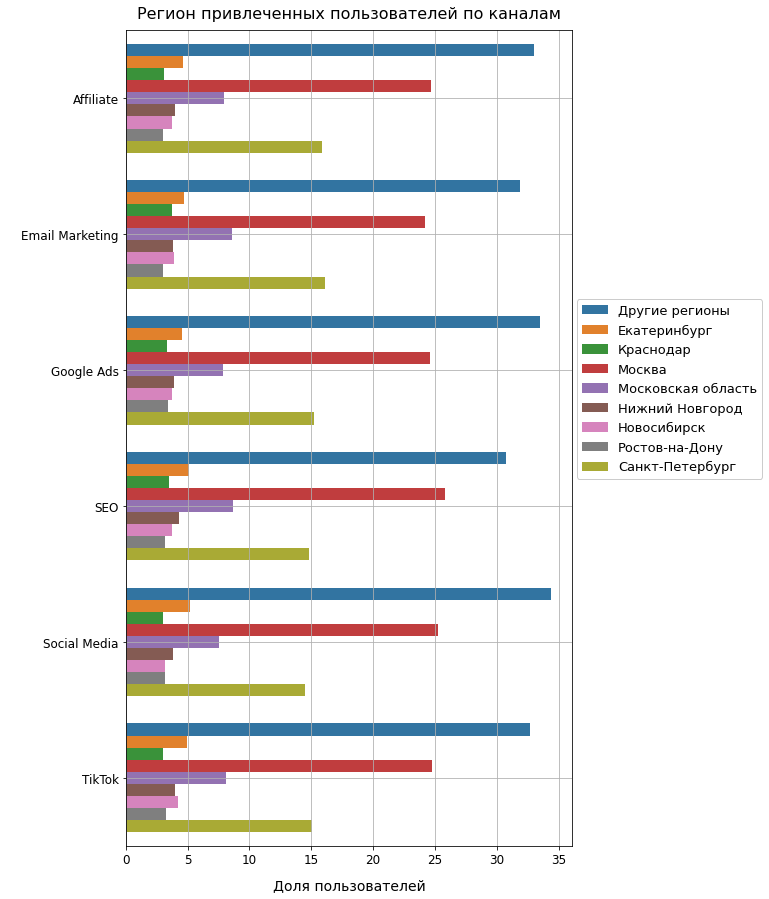

In [39]:
new_users_channel_region = (
    users
        .groupby(['acq_channel', 'region'])
        .agg(new_users=('user_id', 'nunique'))
        .reset_index()
)

# объединяем таблицы и считаем доли
new_users_channel_region = pd.merge(
    new_users_channel_region,
    new_users_ch,
    how='left',
    on='acq_channel'
)

new_users_channel_region['share'] = 100 * (
    new_users_channel_region['new_users']
    / new_users_channel_region['new_users_total']
)

# визуализация
plt.figure(figsize=(8,15))

sns.barplot(
    data=new_users_channel_region, 
    x="share", y="acq_channel", 
    hue="region",
)

plt.title(
    'Регион привлеченных пользователей по каналам',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Доля пользователей',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    ' ',
)

plt.tick_params(
   labelsize=12 
)

plt.legend(
    fontsize=13,
    framealpha=1,
    loc=(1.01, 0.45)
)

plt.grid()

plt.show()

**Промежуточный вывод:** канал TikTok привлекает те же группы по региону, что и другие каналы:
- около 25% пользователей из Москвы
- около 15% пользователей из Питера
- около 7% пользователей из МО
- около 5% пользователей из Екатеринбурга
- до 5% пользователей из Краснодара / Новосибирска / Ростова-на-Дону и Нижнего Новгорода
- 30-35% пользователей из других регионов

##### Различия по каналам по возрастному признаку

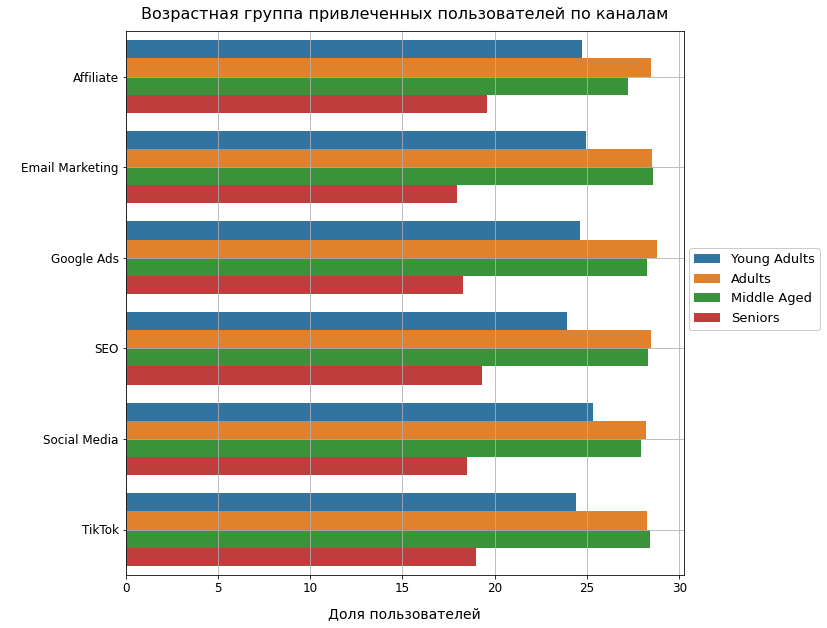

In [40]:
# добавим признак "возрастной сегмент"
users["age_segment"] = pd.cut(
   users["age"], 
    bins=[18, 30, 45, 60, 70], 
    labels=['Young Adults', 'Adults', 'Middle Aged', 'Seniors'],
    include_lowest=True,
)

new_users_channel_age = (
    users
        .groupby(['acq_channel', 'age_segment'])
        .agg(new_users=('user_id', 'nunique'))
        .reset_index()
)

# объединяем таблицы и считаем доли
new_users_channel_age = pd.merge(
    new_users_channel_age,
    new_users_ch,
    how='left',
    on='acq_channel'
)

new_users_channel_age['share'] = 100 * (
    new_users_channel_age['new_users']
    / new_users_channel_age['new_users_total']
)

# визуализация
plt.figure(figsize=(10,10))

sns.barplot(
    data=new_users_channel_age, 
    x="share", y="acq_channel", 
    hue="age_segment",
)

plt.title(
    'Возрастная группа привлеченных пользователей по каналам',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Доля пользователей',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    ' ',
)

plt.tick_params(
   labelsize=12 
)

plt.legend(
    fontsize=13,
    framealpha=1,
    loc=(1.01, 0.45)
)

plt.grid()
plt.show()

**Промежуточный вывод:** канал TikTok привлекает те же возрастные группы, что и другие каналы

#### 4.1.5 Какие товары заказывают пользователи, пришедшие по различным каналам

In [41]:
# посмотрим на наиболее популярные
# категории товаров за год
top_categories = (
        orders
            .groupby('category_name')
            .agg(total_orders=('order_id', 'nunique'))
            .reset_index()
    )

display_with_heading(
    'Наиболее популярные категории товаров',
    top_categories
        .sort_values('total_orders', ascending=False)
        [['category_name']][:3]
)

Наиболее популярные категории товаров:


,category_name
17,Продукты питания
4,Детская одежда
7,Зоотовары


In [42]:
# посмотрим на наиболее популярные
# категории товаров, заказываемые
# пользователями, пришедшими из 
# различны каналов
for channel in orders_users_ch['acq_channel'].unique():
    data = orders_users_ch[orders_users_ch['acq_channel'] ==  channel]
    
    top_categories = (
        data
            .groupby('category_name')
            .agg(total_orders=('order_id', 'nunique'))
            .reset_index()
    )
    
    display_with_heading(
        f'{channel}',
        top_categories.sort_values('total_orders', ascending=False)[['category_name']][:3]
    )

Google Ads:


,category_name
17,Продукты питания
9,Книги и канцтовары
7,Зоотовары


SEO:


,category_name
17,Продукты питания
4,Детская одежда
7,Зоотовары


Social Media:


...

,category_name


Email Marketing:


,category_name
17,Продукты питания
7,Зоотовары
4,Детская одежда


TikTok:


,category_name
17,Продукты питания
20,Сумки и аксессуары
9,Книги и канцтовары


**Промежуточный вывод:** наиболее популярные категории товаров — продукты питания, детская одежда и зоотовары. Пользователи, пришедшие из всех каналов, кроме TikTok, имеют в топе хотя бы 2/3 популярных товаров. Пользователи6 пришедшие из канала TikTok, из популярных категорий заказывают только продукты питания

#### 4.1.6 Изучение удержания пользователей и конверсии "покупатель" -> "пользователь"

Спускаясь по дереву метрик заметили, что причиной ухудшения ключевых метрик является снижение конверсии пользователей в покупателей и ухудшение удержания пользователей. Посмотрим, связано ли это с тем, что основная аудитория стала приходить из другого канала после изменения маркетинговых расходов

##### Конверсия пользователь-покупатель по каналам

In [43]:
# до перераспределения маркетингового бюджета
events_users = pd.merge(
    events,
    users[['user_id', 'acq_channel']],
    how='left',
    on='user_id'
)

viewers_monthly = (
    events_users[
        (events_users['event_type'] == 'product_view')
        & (events_users['event_month'] <= '2024-05-01')
    ]
        .groupby(['acq_channel'])
        .agg(viewers=('user_id', 'nunique'))
        .reset_index()
)


buyers_monthly = (
    events_users[
        (events_users['event_type'] == 'checkout_complete')
        & (events_users['event_month'] <= '2024-05-01')
    ]
        .groupby(['acq_channel'])
        .agg(buyers=('user_id', 'nunique'))
        .reset_index()
)

cr_to_order = pd.merge(
    viewers_monthly,
    buyers_monthly,
    how='inner',
    on=['acq_channel']
)

cr_to_order['cr'] = 100 * (
    cr_to_order['buyers']
    / cr_to_order['viewers']
)

with pd.option_context('display.float_format', '{:.1f}'.format):
    display_with_heading(
        'Конверсия (%) из активного пользователя в покупателя до мая 2024',
        cr_to_order.sort_values('cr')
    )

# после перераспределения
viewers_monthly = (
    events_users[
        (events_users['event_type'] == 'product_view')
        & (events_users['event_month'] >= '2024-06-01')
    ]
        .groupby(['acq_channel'])
        .agg(viewers=('user_id', 'nunique'))
        .reset_index()
)

buyers_monthly = (
    events_users[
        (events_users['event_type'] == 'checkout_complete')
        & (events_users['event_month'] >= '2024-06-01')
    ]
        .groupby(['acq_channel'])
        .agg(buyers=('user_id', 'nunique'))
        .reset_index()
)

cr_to_order = pd.merge(
    viewers_monthly,
    buyers_monthly,
    how='inner',
    on=['acq_channel']
)

cr_to_order['cr'] = 100 * (
    cr_to_order['buyers']
    / cr_to_order['viewers']
)

with pd.option_context('display.float_format', '{:.1f}'.format):
    display_with_heading(
        'Конверсия (%) из активного пользователя в покупателя с июня 2024',
        cr_to_order.sort_values('cr')
    )

Конверсия (%) из активного пользователя в покупателя до мая 2024:


,acq_channel,viewers,buyers,cr
5,TikTok,642,243,37.9
4,Social Media,877,572,65.2
1,Email Marketing,555,376,67.7
2,Google Ads,3090,2114,68.4
3,SEO,938,652,69.5
0,Affiliate,1616,1214,75.1


Конверсия (%) из активного пользователя в покупателя с июня 2024:


,acq_channel,viewers,buyers,cr
5,TikTok,6064,2402,39.6
4,Social Media,1468,953,64.9
1,Email Marketing,826,541,65.5
2,Google Ads,3105,2249,72.4
0,Affiliate,2376,1740,73.2
3,SEO,1424,1043,73.2


**Промежуточный вывод:** пользователи, пришедшие из канала TikTok, имеют самую низкую конверсию в покупателя. Поэтому несмотря на то, что кол-во активных пользователей с сентября снижалось понемногу, кол-во заказов снижалось гораздо быстрее, т.к. большая часть пользователей стала приходить из канала с низкой конверсией из пользователя в покупателя

Но падение кол-ва заказов началось уже в июне (выросшее кол-во новых пользователей отсрочило падение кол-ва заказов). Это могло произойти из-за плохого удержания пользователей

##### Изучение снижения удержания

1. Посмотрим на метрики лояльности пользователей, например, на частоту покупок. Вероятно, худшая возвращаемость пользователей связана с ухудшением пользовательского опыта

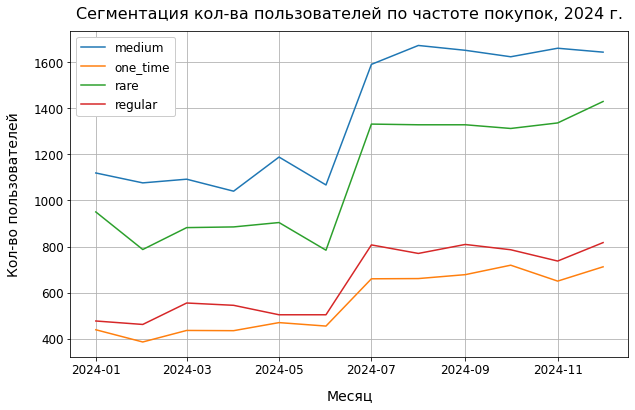

In [44]:
buyer_segments_monthly = (
    users
        .groupby(['cohort_month', 'buyer_segment'])
        .agg(total_users=('user_id', 'count'))
        .reset_index()
)

# визуализация
plt.figure(figsize=(10,6))

sns.lineplot(
    data=buyer_segments_monthly, 
    x='cohort_month', 
    y='total_users', 
    hue='buyer_segment',
)

plt.title(
    'Сегментация кол-ва пользователей по частоте покупок, 2024 г.',
    fontsize=16,
    pad=12,
)

plt.xlabel(
    'Месяц',
    fontsize=14,
    labelpad=12,
)

plt.ylabel(
    'Кол-во пользователей',
    fontsize=14,
    labelpad=12,
)

plt.tick_params(
   labelsize=12 
)
plt.legend(
    fontsize=12,
    framealpha=1,
)
plt.grid()
plt.show()

**Промежуточный вывод:** прирост всех типов покупателей приблизительно одинаков (нет такого, что стали чаще приходить покупатели, совершающие разовые покупки). Можем предположить, что опыт пользователей не изменился (сам маркетплейс хуже не стал, но стало приходить больше незаинтересованных пользователей)

2. Удержание пользователей по каналам

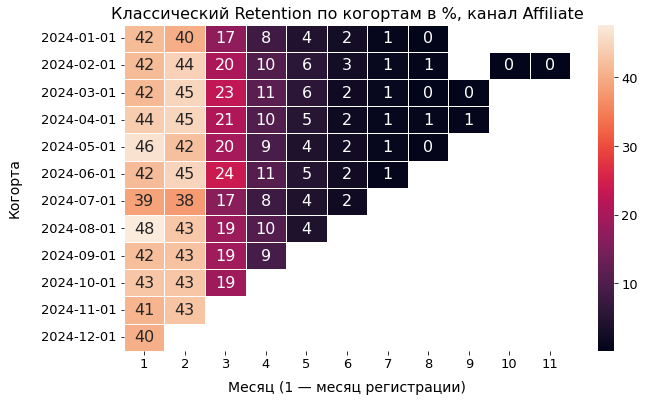

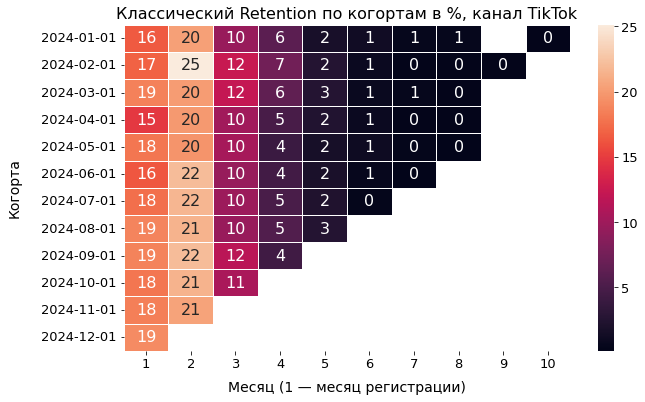

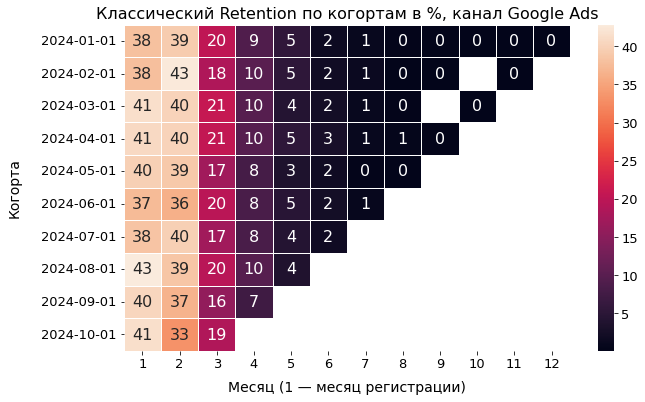

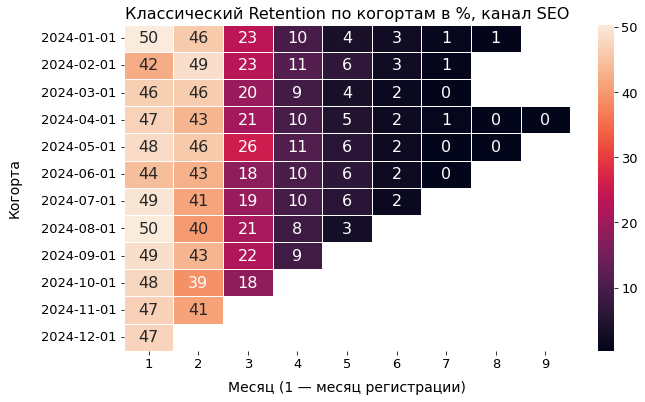

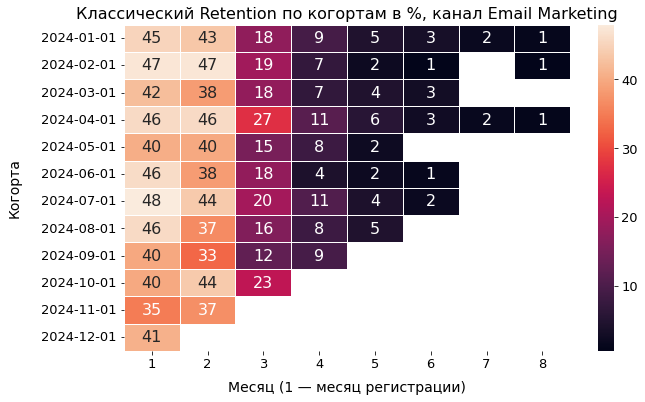

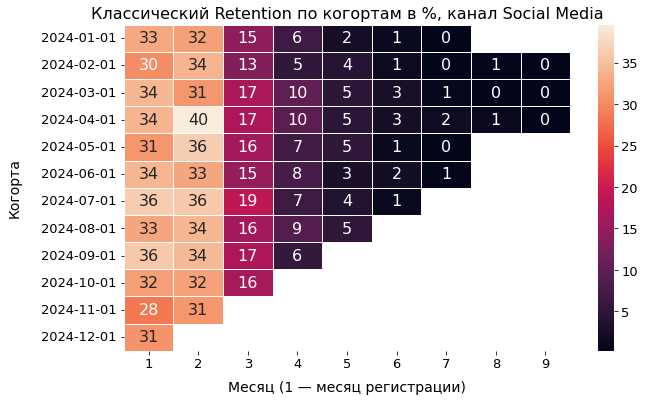

In [45]:
# отфильтруем таблицу events
events_by_users_from_2024 = (
    events[events['user_id'].isin(users['user_id'])]
)

# объединим данные из таблицы events 
# и таблицы users
data_for_classic_retention = pd.merge(
    events_by_users_from_2024[['user_id', 'event_month']],
    users[['user_id', 'cohort_month', 'acq_channel']],
    how='inner',
    on='user_id'
)

# т.к. смотрим, возвращался ли пользователь
# в конкретный месяц, удалим полные дубликаты
data_for_classic_retention.drop_duplicates(inplace=True, ignore_index=True)

for channel in data_for_classic_retention['acq_channel'].unique():    # рассчитаем кол-во активных пользователей
    # каждой когорты помесячно
    data_for_classic_retention_gr = (
        data_for_classic_retention[
            data_for_classic_retention['acq_channel'] == channel
        ]
            .groupby(['cohort_month', 'event_month'])
            .agg(total_users=('user_id', 'count'))
            .reset_index()
    )

    # добавим информацию о кол-ве пользователей,
    # зарегистрировавшихся в этой когорте
    data_for_classic_rr_plus_reg = pd.merge(
        data_for_classic_retention_gr,
        new_users_monthly_ch[
            new_users_monthly_ch['acq_channel'] == channel
        ],
        how='left',
        on='cohort_month'
    )

    # рассчитаем кол-во активных пользователей
    # ежемесячно как долю от зарегистрировавшися
    data_for_classic_rr_plus_reg['rr'] = 100 * (
        data_for_classic_rr_plus_reg['total_users']
        / data_for_classic_rr_plus_reg['new_users']
    )

    # также выведем номер месяца относительно
    # месяца регистрации когорты
    data_for_classic_rr_plus_reg['n_period'] = (
        1 + data_for_classic_rr_plus_reg['event_month'].dt.to_period('M').astype('int64')
        - data_for_classic_rr_plus_reg['cohort_month'].dt.to_period('M').astype('int64')
    )

    
    # перегруппируем данные так, чтобы для
    # было удобно сравнивать удержание 
    # по когортам помесячно
    retention_data = (
        data_for_classic_rr_plus_reg.pivot(
            index='cohort_month',
            columns='n_period',
            values='rr'
        )
    )

    # визуализируем удержание
    retention_data.index = pd.to_datetime(retention_data.index).strftime('%Y-%m-%d')

    plt.subplots(figsize=(10,6))
    ax = sns.heatmap(
        retention_data,
        annot=True,
        fmt=".0f",
        linewidth=0.5,
        annot_kws={"size": 16},
        cbar=True,
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=13)


    plt.title(f'Классический Retention по когортам в %, канал {channel}', fontsize=16)
    plt.xlabel('Месяц (1 — месяц регистрации)', size=14, labelpad=10)
    plt.ylabel('Когорта', size=14, labelpad=20)
    plt.tick_params(labelsize=13)
    plt.show()

**Промежуточный вывод:** из канала TikTok приходят пользователи с самым низким коэффициентом удержания

### Выводы по проекту

1. Единственным замеченным изменением было изменение маркетинговых расходов
- отказались от канала привлечения (Google Ads), который приводил наибольшее кол-во платящих пользователей с хорошей возвращаемостью в продукт;
- вложились в канал привлечения (TikTok), из которого приходили наименее активно совершающие заказы пользователи (конверсия в покупателя вдвое хуже, чем у пользователей из дргуих каналов) с наихудшим коэффициентом возвращаемости (показатель в 1.5-2.5 раза хуже, чем по другим каналам)

Вывод: маркетинговая стратегия была ошибочной, привлечение большего кол-ва пользователей из канала TikTok не дало улучшения ключевых метрик, а наоборот, ухудшило их

2. Чем канал TikTok отличается от остальных каналов? - Наиболее популярными категориями товаров

Вывод: возможно, выставлены неправильные настройки таргетированной рекламы в канале TikTok

3. Также в ходе анализа были получены следующие инсайты:
- на декабрь 2024 всего лишь четверть привлеченных пользователей становятся активными пользователями маркетплейса 
- из них менее половины совершает хотя бы один заказ

Вывод: необходимо работать над началом пути пользователя (регистрация -> вход на маркетплейс), например:
- добавить рекламную рассылку / уведомление недавно зарегистрировавшимся пользователям
- дать промокод на скидку на первый заказ

### Рекомендации:
- вернуться к работе с каналом привлечения Google Ads
- маркетинговый бюджет, который был добавлен каналу привлечения TikTok в июле, перераспределить между каналами Affiliate, SEO и Google Ads (каналами, пользователи из которых активно покупают и хорошо возвращаются в продукт)
- изучить и возможно исправить настройки рекламы в канале TikTok
- добавить рекламную рассылку или уведомление с промокодом на скидку на первый заказ с маркетплейса или совершить другое действие, чтобы повысить конверсию в первый заказ на маркетплейсе

Критический вопрос для эксперимента: Можно ли "спасти" TikTok-трафик через изменение продуктовых механик (например, бонус на первую покупку), или канал фундаментально не подходит для маркетплейса?

### Гипотезы:
- если отправлять недавно зарегистрировавшимся пользователям (например, неделю назад) рекламную рассылку или уведомление с промокодом на первый заказ, конверсия в первый заказ вырастет
- если изменить настройки таргетированной рекламы в TikTok, добавив хэштеги, относящиеся к детям/животным, возвращаемость пользователей из этого канала вырастет
- если изменить настройки таргетированной рекламы в TikTok, добавив хэштеги, относящиеся к детям/животным, конверсия покупку для пользователей из этого канала вырастет